## **1. Introduction**

In this work, three fundamental techniques studied in the Machine Learning 1 course were applied: XGBoost, Logistic Regression, and Neural Networks. These algorithms were used to predict the football results of national teams, which can be classified as a win, draw, or loss. The objective consists of analyzing and comparing different classification approaches regarding their characteristics, performance, and limitations.

For the development of this work, a dataset containing all national team match results from 1872 to mid-2026 is used. The attributes present in the dataset are described below:  

1. **date**: Date when the match took place;
2. **home_team**: Home team;  
3. **away_team**: Away team;  
4. **home_score**: Goals scored by the home team;  
5. **away_score**: Goals scored by the away team;  
6. **tournament**: Type of competition (World Cup, Copa América, Euro, etc.);  
7. **city**: City where the match was played;  
8. **country**: Country where the match was played;
9. **neutral**: Indicates whether the match was played on neutral ground;  

In addition, two auxiliary datasets were used to enrich the representation of the matches and capture aspects not present in the main dataset. The first one refers to structured information from the World Cup, allowing the identification of the match stage within the tournament, such as the group stage, round of 16, quarter-finals, semi-finals, and final. This information is relevant as it reflects natural variations in the level of competitiveness in a competition.

The second dataset is based on team strength ratings from squad attributes derived from FIFA data. These values are known as "overall", which represents a player's general rating and is defined from real performance observations, match analysis, scout reports, and technical evaluations made by the teams responsible for the data. For this reason, the overall rating is used as a standard measure of player strength. This information was aggregated by nationality, calculating the average of the players for each national team. Different configurations were used, such as the average of the top 23 summonable players, the top 11 starting players, and also the top 5 players per sector (attack, midfield, and defense), all sorted by overall rating. This approach allows estimating the overall strength and quality of the sectors for each national team based on their main players.

With the objective of improving supervised classification, the attributes of these datasets were selected, enhanced, and transformed. First, it is important to define and demonstrate how an ELO rating system for the teams was implemented, whose formula is described on the following website https://www.footballdatabase.com/methodology and will be presented below:
$$
R' = R + K \cdot G \cdot (W - W_e)
$$

- $R'$: Is the new ELO; 
- $R$: Is the current ELO;  
- $K$: Is the match importance factor, which depends on the type of competition;
- $G$: Is the goal difference factor;
- $W$: Is the actual result;  
- $W_e$: Is the expected result;  

Where the expected result $W_e$, in terms of the difference between the ELO of the home team and that of the away team ($\Delta R$), is calculated by:

$$
W_e = \frac{1}{10^{-\frac{\Delta R}{400}} + 1}
$$

After this important definition of the ELO system, it is highlighted that the newly constructed dataset features the following attributes:

1. **date**: Date when the match took place;  
2. **home_team**: Home team;  
3. **away_team**: Away team;  
4. **home_elo**: ELO of the home team;  
5. **away_elo**: ELO of the away team;  
6. **elo_diff**: Difference between the ELOs of the home and away teams;  
7. **home_scored**: Average goals scored by the home team in the last 5 matches;  
8. **home_conceded**: Average goals conceded by the home team in the last 5 matches;  
9. **away_scored**: Average goals scored by the away team in the last 5 matches;  
10. **away_conceded**: Average goals conceded by the away team in the last 5 matches;  
11. **home_goal_balance**: Average goal difference of the home team in the last 5 matches;  
12. **away_goal_balance**: Average goal difference of the away team in the last 5 matches;  
13. **goal_balance_diff**: Difference between the average goal differences of the home and away teams in the last 5 matches;  
14. **winrate_home**: Performance rate of the home team in the last 10 matches (considering 3 points for a win and 1 point for a draw);  
15. **winrate_away**: Performance rate of the away team in the last 10 matches (considering 3 points for a win and 1 point for a draw);  
16. **is_home_advantage**: Indicates whether the match was played with home advantage (1) or on neutral ground (0);  
17. **is_worldcup**: Defines whether the match belongs to the World Cup;  
18. **is_continental**: Defines whether the match belongs to continental competitions (such as Copa América, qualifiers, etc.);  
19. **result**: Final match result, where 0 indicates a home team win, 1 indicates a draw, and 2 indicates an away team win;  
20. **home_winrate**: Performance rate of the home team in recent matches, considering scoring based on wins (3 points) and draws (1 point);  
21. **away_winrate**: Performance rate of the away team in recent matches, considering scoring based on wins (3 points) and draws (1 point);  
22. **winrate_diff**: Difference between the performance rates of the home and away teams;  
23. **home_momentum_20**: Performance indicator based on the ELO variation of the home team over a 20-match window;  
24. **away_momentum_20**: Performance indicator based on the ELO variation of the away team over a 20-match window;  
25. **home_momentum_80**: Performance indicator based on the ELO variation of the home team over an 80-match window;  
26. **away_momentum_80**: Performance indicator based on the ELO variation of the away team over an 80-match window;  
27. **stage**: Competition in which the match was played, reflecting the level of importance of the match and, in the case of the World Cup, the specific stages are defined (semi-final, final, etc.); 
28. **home_top23_overall_mean**: Average overall rating of the top 23 summonable players from the home team;  
29. **home_top11_overall_mean**: Average overall rating of the top 11 players from the home team;  
30. **home_attack_top5_mean**: Average overall rating of the top 5 players from the home team with an offensive position;  
31. **home_creation_top5_mean**: Average overall rating of the top 5 players from the home team with a creative midfield position;  
32. **home_defense_top5_mean**: Average overall rating of the top 5 players from the home team with a defensive position;  
33. **away_top23_overall_mean**: Average overall rating of the top 23 summonable players from the away team;  
34. **away_top11_overall_mean**: Average overall rating of the top 11 players from the away team;  
35. **away_attack_top5_mean**: Average overall rating of the top 5 players from the away team with an offensive position;  
36. **away_creation_top5_mean**: Average overall rating of the top 5 players from the away team with a midfield position;  
37. **away_defense_top5_mean**: Average overall rating of the top 5 players from the away team with a defensive position;


Dataset Sources:

1. National team matches: https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017
2. World Cup historical data: https://www.kaggle.com/datasets/abhijitdahatonde/fifa-world-cup-all-dataset
3. Data for all players from Fifa 15 to 24: https://www.kaggle.com/datasets/joebeachcapital/fifa-players
4. Data for all players from Fifa 25: https://www.kaggle.com/datasets/nyagami/ea-sports-fc-25-database-ratings-and-stats
5. Data for all players from Fifa 26: https://www.kaggle.com/datasets/rovnez/fc-26-fifa-26-player-data

## Libraries

In [2]:
import csv
from collections import defaultdict, deque
import pandas as pd
import numpy as np
import os, warnings, json
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, log_loss, confusion_matrix, classification_report,
)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier


## **2. Data Visualization**

For a better analysis of the newly generated dataset, some graphical visualizations were performed. Among them, the correlation heatmap of all numerical attributes in the dataset stands out initially. This type of chart is important for checking possible redundancies between attributes, generally indicated by high correlation values. It can be observed that some attributes have high correlation with each other, such as "home_goal_balance" and "home_conceded". Despite this, these relationships do not harm the quality of the dataset for use in supervised learning, since, in general, there is no significant overlap of information between the attributes.


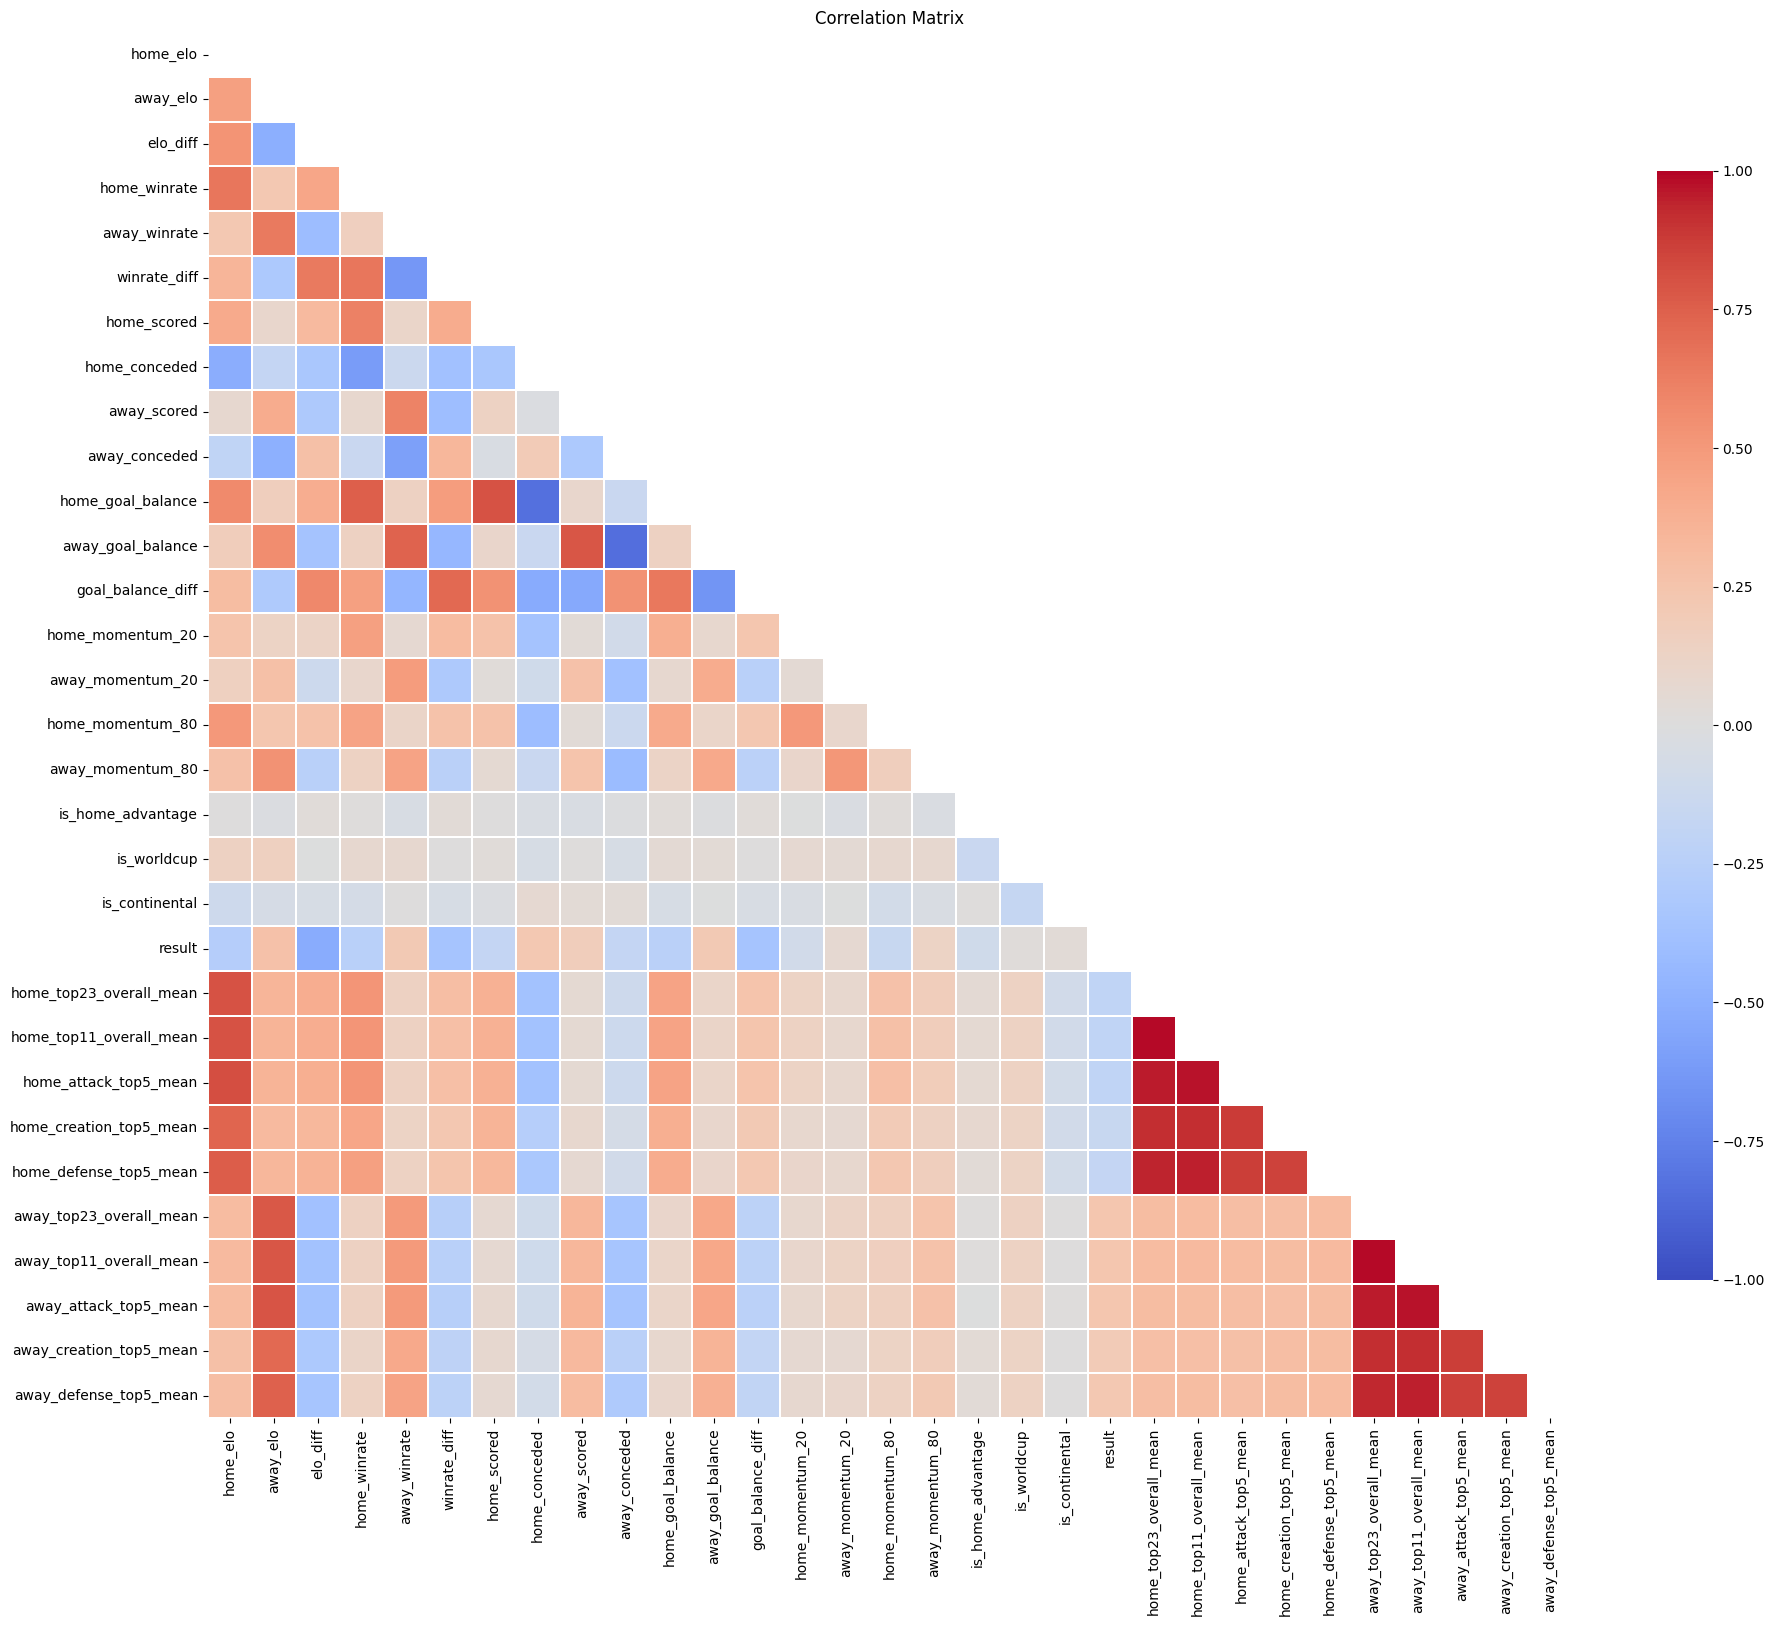

In [3]:
dataset = pd.read_csv("FinalDataset.csv")
corr = dataset.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(22,18))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    center=0,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix")
plt.show()

The histogram of match result classes was also analyzed, showing that the number of wins for the "home" teams is almost double that of the visiting teams. This imbalance is an important factor for analyzing the possible outcomes of supervised learning, since it influences the interpretation of accuracy. It is worth noting that the classification models should perform better than a naive classifier that always predicts a home team win.


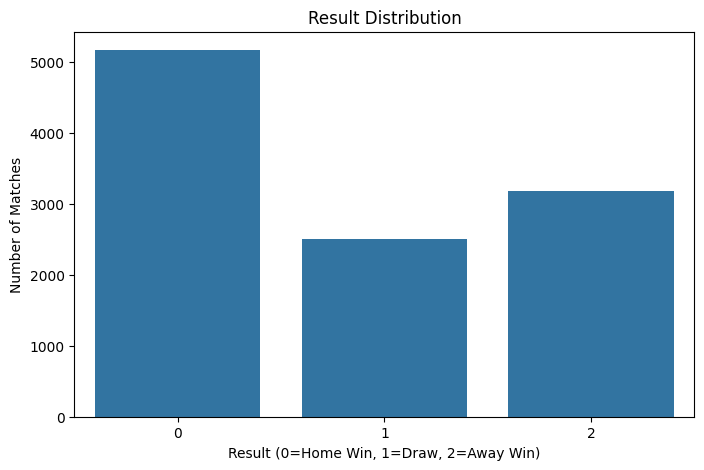

In [4]:
dataset = pd.read_csv("FinalDataset.csv")

plt.figure(figsize=(8,5))
sns.countplot(x="result", data=dataset)

plt.title("Result Distribution")
plt.xlabel("Result (0=Home Win, 1=Draw, 2=Away Win)")
plt.ylabel("Number of Matches")

plt.show()

Scatter plots were also examined, in which the attributes "elo_diff" and "winrate_diff" show a relationship with the match result. It can be observed that home and away wins have good separability between them, while draws tend to concentrate in the intermediate region, with greater overlap with the other results. It is worth noting that this result is consistent, since matches between teams of similar level tend to show greater balance in outcomes. Furthermore, when analyzing the relationship between the attributes "goal_balance_diff" and "winrate_diff", a similar behavior is observed, with some differences in data dispersion. It is noteworthy that "goal_balance_diff" shows a more concentrated variation and greater overlap in the intermediate region between classes, with the chart displaying a greater inclination relative to the first.

In both charts, some outliers can be observed, representing matches with atypical behaviors, such as unexpected results, wins with large goal differences, and/or performances outside the statistical standard of the teams. These points are expected, since football is a stochastic sport in which various factors can influence match results.


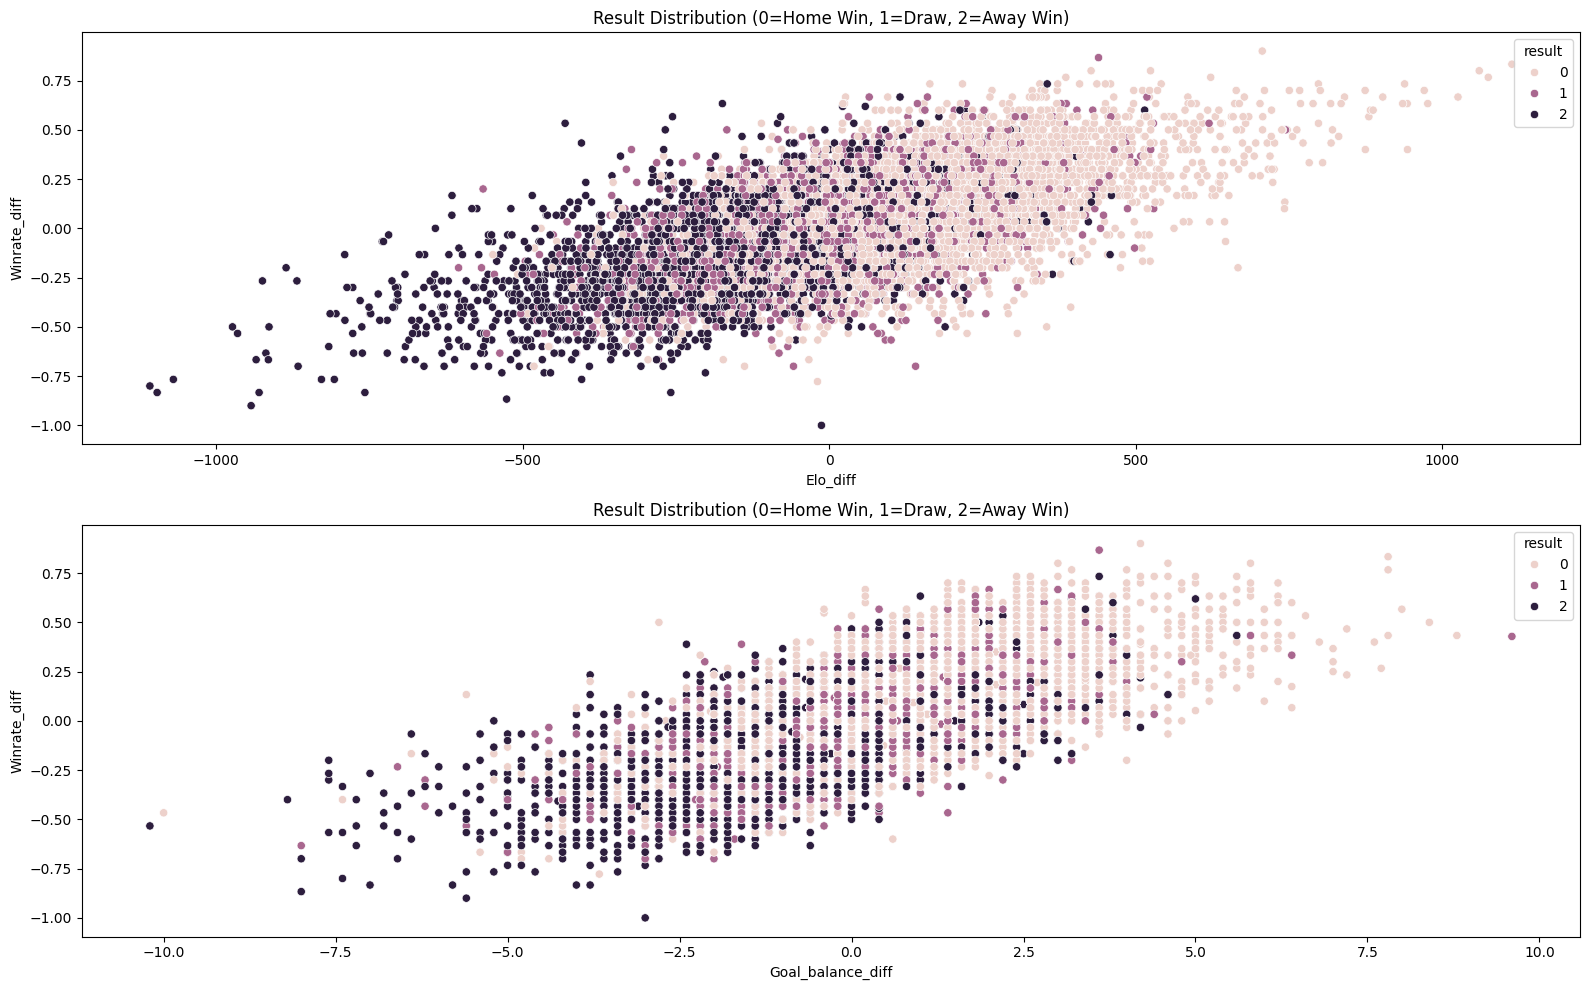

In [5]:
dataset = pd.read_csv("FinalDataset.csv")

plt.figure(figsize=(16,10))
plt.subplot(2,1,1)
sns.scatterplot(data = dataset, x = "elo_diff", y = "winrate_diff", hue = "result")

plt.title("Result Distribution (0=Home Win, 1=Draw, 2=Away Win)")
plt.xlabel("Elo_diff")
plt.ylabel("Winrate_diff")

plt.subplot(2,1,2)
sns.scatterplot(data = dataset, x = "goal_balance_diff", y = "winrate_diff", hue = "result")

plt.title("Result Distribution (0=Home Win, 1=Draw, 2=Away Win)")
plt.xlabel("Goal_balance_diff")
plt.ylabel("Winrate_diff")

plt.tight_layout()
plt.show()

Finally, the distribution of the attributes with the highest absolute correlation values with the results was analyzed, and the variables "winrate_diff" and "elo_diff" were selected. It is worth noting that the objective is to analyze their dispersion and outliers, since these characteristics can influence supervised learning, as high variability and the presence of extreme values can affect classifications. In the winrate_diff boxplot, the median is close to 0, indicating a balanced distribution across matches. Additionally, there is a slight, barely noticeable negative asymmetry and the data dispersion can be considered moderate, with outliers observed both positively and negatively, representing matches with more extreme performances.

In the elo_diff boxplot, a smaller box is observed compared to winrate_diff, indicating lower relative data dispersion. Additionally, a slight, barely noticeable negative asymmetry is noted with the median value close to zero, again suggesting a balanced distribution of matches. It is worth highlighting the presence of a large number of outliers, which evidences the occurrence of several matches with high competitive level differences.

In general, the analyzed attributes show a relatively balanced distribution, with the presence of outliers that may influence supervised learning performance. These extreme values may be associated with matches with atypical results, such as very unbalanced wins, which can positively influence the model's ability to recognize these scenarios, but also negatively impact the model's performance in more balanced matches. Thus, the importance of subsequently evaluating the effect of these observations on accuracy after model training is highlighted.


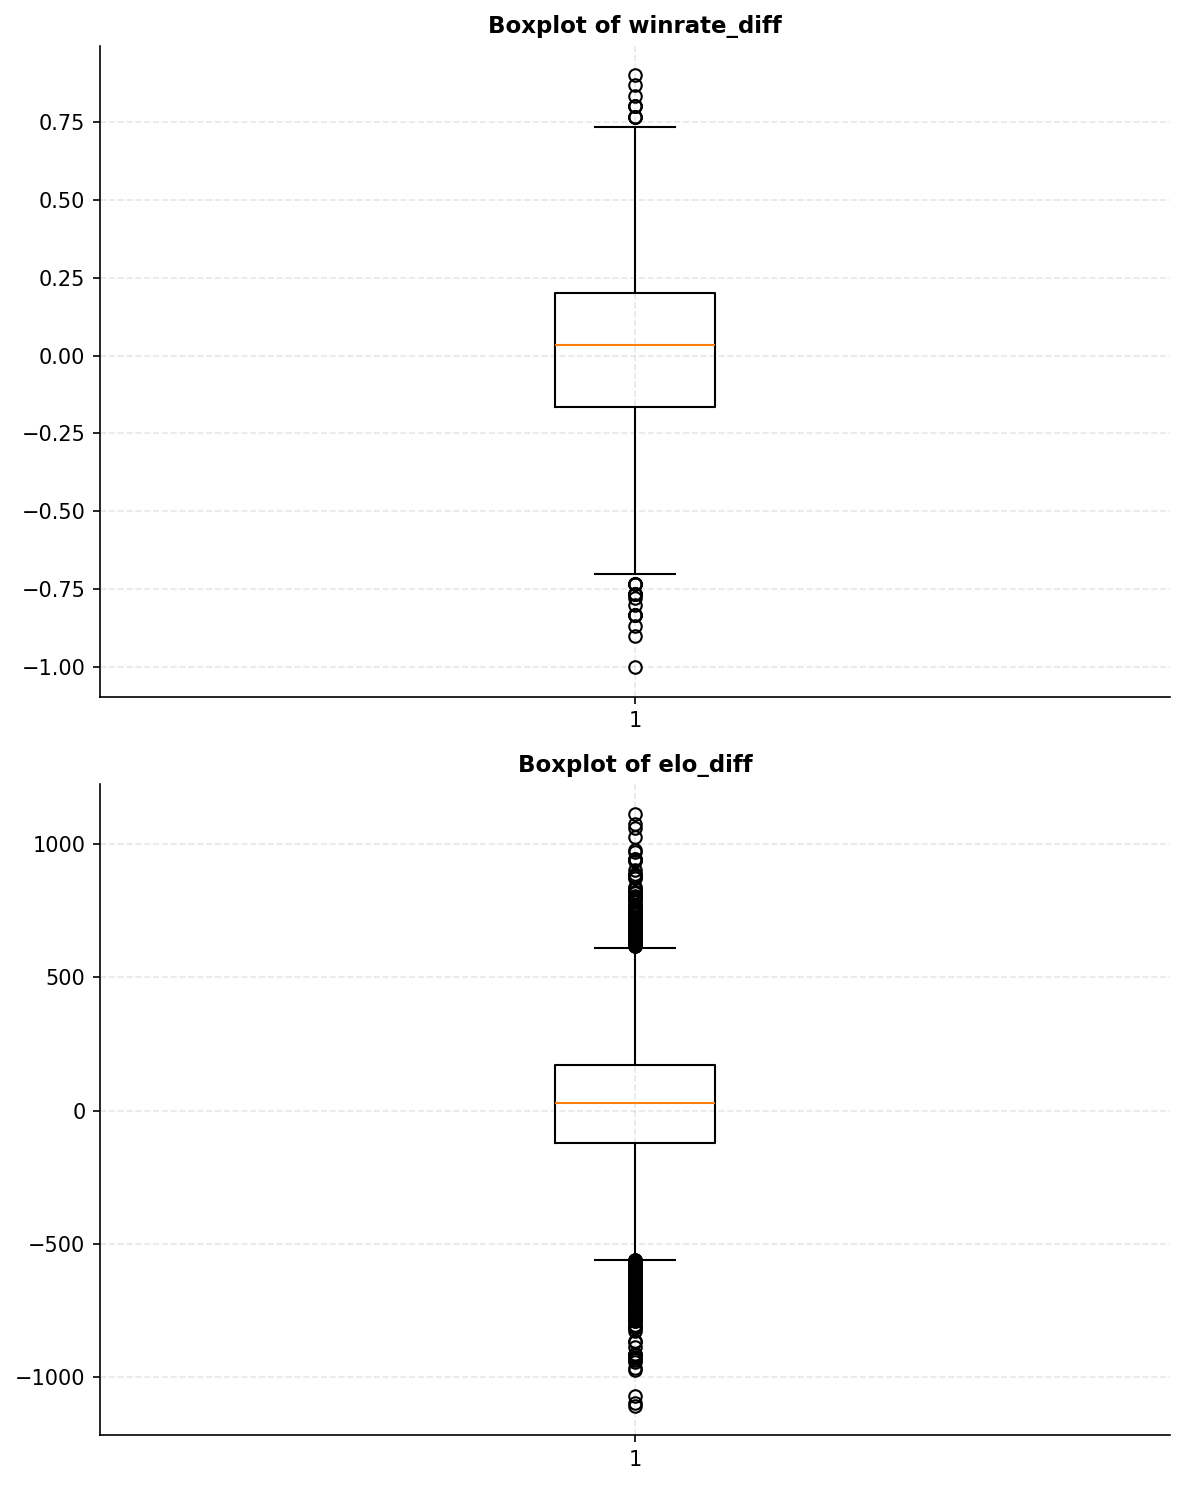

In [30]:
dataset = pd.read_csv("FinalDataset.csv")

plt.figure(figsize=(8,10))
plt.subplot(2,1,1)
plt.boxplot(dataset["winrate_diff"])
plt.title("Boxplot of winrate_diff")

plt.subplot(2,1,2)
plt.boxplot(dataset["elo_diff"])
plt.title("Boxplot of elo_diff")

plt.tight_layout()
plt.show()

## 3. Supervised Learning

In this section, three supervised learning techniques are applied: Logistic Regression, XGBoost, and Neural Networks, with the objective of classifying results into win, draw, and loss. For each model, performance metrics such as accuracy, precision, and recall are presented, along with analyses based on the confusion matrix, allowing evaluation of the effectiveness of each approach. It is worth noting that the data were split using a temporal separation approach, in which older samples were used for training and more recent ones for testing. This strategy was adopted to preserve the temporal dependency of the variables and avoid future information leakage, ensuring a more realistic evaluation of model performance.

It is observed that the data are organized temporally, since each match depends only on what happened before it and not on the future. Therefore, the following validation and training methods were used: Rolling Window and Expanding Window. Rolling Window involves training the model only with a fixed recent period, prioritizing the most current behavior of the national teams and capturing rapid changes in football, such as tactical evolution and performance variations over the years. Expanding Window, on the other hand, uses all available history up to that point, allowing the model to learn more general football patterns over time. The comparison between these two methods is important, since football is highly dynamic — national teams, coaches, and playing styles can change significantly in just a few months — making it essential to evaluate whether the model benefits more from broad historical knowledge or from a greater emphasis on recent data.

Furthermore, model evaluation is performed using different performance metrics, in order to capture not only the overall hit rate, but also the model's behavior in each class. These include accuracy, which measures the overall classifier performance; precision and recall, which evaluate respectively the hit rate among positive predictions and the ability to correctly identify each class; and the F1-score, which combines these two metrics into a balanced measure. Both the per-class F1-score and the macro and weighted averages are analyzed, allowing evaluation of the model's balance regarding class imbalance. In addition, log loss is used, which evaluates the quality of the probabilities predicted by the models, being relevant as it is a probabilistic classification approach.

To ensure the reproducibility of classifications and the organization of results, a utility module was developed to automate the entire model evaluation pipeline. This module centralizes data loading and preprocessing, generation of temporal validation windows (Rolling Window and Expanding Window), model training, and calculation of performance metrics. Furthermore, all experiments are executed in a standardized manner, automatically varying between different feature configurations and balancing strategies, with results stored in CSV files. This approach allows comparison between different models and scenarios, facilitating result analysis through tables and graphical visualizations, to be discussed in the following section. It is worth noting that the different feature configurations tested are:

1. Full features with One-Hot Encoding of the stage variable, using Rolling Window without class balancing;
2. Full features with One-Hot Encoding of the stage variable, using Expanding Window without class balancing;
3. Full features with One-Hot Encoding of the stage variable, using Rolling Window with class balancing (draw weight of 1.4);
4. Full features with One-Hot Encoding of the stage variable, using Expanding Window with class balancing (draw weight of 1.4);
5. Using only the elo_diff variable as model input, using Rolling Window without class balancing;
6. Using only the elo_diff variable as model input, using Expanding Window without class balancing;
7. Using only the elo_diff variable as model input, using Rolling Window with class balancing (draw weight of 1.4);
8. Using only the elo_diff variable as model input, using Expanding Window with class balancing (draw weight of 1.4);
9. Full features with One-Hot Encoding of the stage variable, using Rolling Window without the elo_diff variable;
10. Full features with One-Hot Encoding of the stage variable, using Expanding Window without the elo_diff variable;
11. Full features with One-Hot Encoding of the stage variable, using Rolling Window without the elo_diff variable and with class balancing (higher draw weight of 1.4);
12. Full features with One-Hot Encoding of the stage variable, using Expanding Window without the elo_diff variable and with class balancing (higher draw weight of 1.4);

Source: https://robotwealth.com/rolling-and-expanding-windows-for-dummies/


### Functions

In [7]:
#========== GLOBAL PARAMETERS (change here for all classifiers)===============
DATASET_PATH = "FinalDataset.csv"
RESULTS_DIR  = "results"

# Rolling Window
ROLLING_TRAIN_YEARS = 4 # training years
ROLLING_TEST_YEARS  = 2 # test years

# Expanding Window
EXPANDING_INITIAL_TRAIN_YEARS = 4   # initial training
EXPANDING_STEP_YEARS = 2   # step (test years + expansion)

# Balancing — draw weight (class 1)
DRAW_WEIGHT = 1.4 # 1.0 = no balancing

# ELO-related columns removed in the "no_elo" experiments
ELO_COLS = [
    "home_elo", "away_elo", "elo_diff",
    "home_momentum_20", "away_momentum_20",
    "home_momentum_80", "away_momentum_80",
]

CLASSES = [0, 1, 2]
os.makedirs(RESULTS_DIR, exist_ok=True)



# =======LOADING AND PREPROCESSING=======


def load_dataset():
    df = pd.read_csv(DATASET_PATH)
    df["date"] = pd.to_datetime(df["date"])
    return df.sort_values("date").reset_index(drop=True)


#Full features with One-Hot Encoding on 'stage'."""
def prepare_features_complete(df):
    df = pd.get_dummies(df.copy(), columns=["stage"], prefix="stage", dtype=int)
    drop = [c for c in ["date", "home_team", "away_team", "result"] if c in df.columns]
    return df.drop(columns=drop), df["result"].values


#Full features without ELO and momentum columns."""
def prepare_features_no_elo(df):
    df = pd.get_dummies(df.copy(), columns=["stage"], prefix="stage", dtype=int)
    drop = [c for c in ["date", "home_team", "away_team", "result"] + ELO_COLS if c in df.columns]
    return df.drop(columns=drop), df["result"].values


#Only elo_diff as feature."""
def prepare_features_elo(df):
    return df[["elo_diff"]].copy(), df["result"].values


# NORMALIZATION — applied fold by fold, without data leakage

"""
Imputer(median) + StandardScaler fitted ONLY on training. The test fold only receives transform(), never fit().
"""
def normalize(X_train, X_test):
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_tr = scaler.fit_transform(imputer.fit_transform(X_train))
    X_te = scaler.transform(imputer.transform(X_test))
    return X_tr, X_te


# WINDOW GENERATORS-----------------

"""
Sliding window: fixed training, shifts 1 year at a time.
Ex (4 train, 2 test): 2015-18→2019-20 | 2016-19→2020-21 |
"""
def generate_rolling_window(df, train_years=ROLLING_TRAIN_YEARS, test_years=ROLLING_TEST_YEARS):
    anos = df["date"].dt.year
    min_y, max_y = int(anos.min()), int(anos.max())
    fold, ts = 1, min_y
    while True:
        te = ts + train_years - 1
        vs, ve = te + 1, te + test_years
        if ve > max_y:
            break
        ti = df[(anos >= ts) & (anos <= te)].index.tolist()
        vi = df[(anos >= vs) & (anos <= ve)].index.tolist()
        if ti and vi:
            yield fold, ti, vi, f"{ts}-{te}", f"{vs}-{ve}"
        fold += 1
        ts   += 1


"""
Expanding window: training grows at each fold.
Ex (4 initial, 2 step): 2015-18→2019-20 | 2015-20→2021-22 |
"""
def generate_expanding_window(df, initial=EXPANDING_INITIAL_TRAIN_YEARS, step=EXPANDING_STEP_YEARS):
    anos = df["date"].dt.year
    min_y, max_y = int(anos.min()), int(anos.max())
    fold, vs = 1, min_y + initial
    while True:
        ve = vs + step - 1
        if ve > max_y:
            break
        ti = df[(anos >= min_y) & (anos <= vs - 1)].index.tolist()
        vi = df[(anos >= vs)    & (anos <= ve)].index.tolist()
        if ti and vi:
            yield fold, ti, vi, f"{min_y}-{vs-1}", f"{vs}-{ve}"
        fold += 1
        vs   += step



# SAMPLE WEIGHTS-----------------

def calculate_weights(y_train, draw_weight=DRAW_WEIGHT):
    w = np.ones(len(y_train), dtype=float)
    w[y_train == 1] = draw_weight
    return w


# FOLD EVALUATION-----------------------

def evaluate_fold(y_true, y_pred, y_proba, fold_num, train_period, test_period):
    prec = precision_score(y_true, y_pred, average=None, labels=CLASSES, zero_division=0)
    rec  = recall_score (y_true, y_pred, average=None, labels=CLASSES, zero_division=0)
    f1   = f1_score (y_true, y_pred, average=None, labels=CLASSES, zero_division=0)
    return {
        "fold" : fold_num,
        "train" : train_period,
        "test" : test_period,
        "n_test" : len(y_true),
        "accuracy" : round(accuracy_score(y_true, y_pred), 4),
        "precision_class0": round(float(prec[0]), 4),
        "precision_class1": round(float(prec[1]), 4),
        "precision_class2": round(float(prec[2]), 4),
        "recall_class0" : round(float(rec[0]),  4),
        "recall_class1" : round(float(rec[1]),  4),
        "recall_class2" : round(float(rec[2]),  4),
        "f1_class0" : round(float(f1[0]),   4),
        "f1_class1" : round(float(f1[1]),   4),
        "f1_class2" : round(float(f1[2]),   4),
        "f1_macro" : round(f1_score(y_true, y_pred, average="macro",    zero_division=0), 4),
        "f1_weighted" : round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "log_loss" : round(log_loss(y_true, y_proba, labels=CLASSES), 4),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=CLASSES).tolist(),
    }


# FOLD AVERAGES---------------------
def calculate_averages(results):
    metricas = [
        "accuracy",
        "precision_class0", "precision_class1", "precision_class2",
        "recall_class0",    "recall_class1",    "recall_class2",
        "f1_class0",        "f1_class1",        "f1_class2",
        "f1_macro", "f1_weighted", "log_loss",
    ]
    averages = {m: round(float(np.mean([r[m] for r in results])), 4) for m in metricas}
    cm_total = np.zeros((3, 3), dtype=int)
    for r in results:
        cm_total += np.array(r["confusion_matrix"])
    averages["confusion_matrix_total"] = cm_total.tolist()
    return averages


# SAVING — CSV only=============

def save_results(experiment_name, results, averages, subdir=""):
    save_dir = os.path.join(RESULTS_DIR, subdir) if subdir else RESULTS_DIR
    os.makedirs(save_dir, exist_ok=True)

    # One fold per row (without the confusion_matrix column)
    rows = [{k: v for k, v in r.items() if k != "confusion_matrix"} for r in results]

    # Averages row — accumulated confusion_matrix as readable string
    cm = averages["confusion_matrix_total"]
    media_row = {
        "fold": "AVERAGE", "train": "-", "test": "-",
        **{k: v for k, v in averages.items() if k != "confusion_matrix_total"},
        "confusion_matrix_total": str(cm),
    }
    rows.append(media_row)

    csv_path = os.path.join(save_dir, f"{experiment_name}.csv")
    pd.DataFrame(rows).to_csv(csv_path, index=False)
    print(f"  → Saved: {csv_path}")


def print_summary(name, averages):
    print(f"\n{'─'*60}")
    print(f"  SUMMARY: {name}")
    print(f"{'─'*60}")
    print(f"  Accuracy          : {averages['accuracy']:.4f}")
    print(f"  Precision C0/C1/C2: {averages['precision_class0']:.4f} / {averages['precision_class1']:.4f} / {averages['precision_class2']:.4f}")
    print(f"  Recall    C0/C1/C2: {averages['recall_class0']:.4f} / {averages['recall_class1']:.4f} / {averages['recall_class2']:.4f}")
    print(f"  F1        C0/C1/C2: {averages['f1_class0']:.4f} / {averages['f1_class1']:.4f} / {averages['f1_class2']:.4f}")
    print(f"  F1-Macro          : {averages['f1_macro']:.4f}  |  F1-Weighted: {averages['f1_weighted']:.4f}")
    print(f"  Log-Loss          : {averages['log_loss']:.4f}")
    cm = np.array(averages["confusion_matrix_total"])
    print(f"  Confusion Matrix (accumulated):")
    print(f"               Prev C0  Prev C1  Prev C2")
    for i, lbl in enumerate(["Actual C0 (H.Win)", "Actual C1 (Draw)", "Actual C2 (A.Win)"]):
        print(f"  {lbl:16s}  {cm[i,0]:7d}  {cm[i,1]:7d}  {cm[i,2]:7d}")



# RUNNING AN EXPERIMENT===================

def run_experiment(name, df, X, y, train_fn, window_type, use_balancing):
    print(f"\n{'='*60}")
    print(f"  EXPERIMENT: {name}")
    print(f"  Window: {window_type} | Balancing: {use_balancing}")
    print(f"{'='*60}")

    generator  = generate_rolling_window(df) if window_type == "rolling" else generate_expanding_window(df)
    results    = []

    for fold, tr_idx, te_idx, tp, vp in generator:
        X_tr_raw, X_te_raw = X.loc[tr_idx], X.loc[te_idx]
        y_tr, y_te         = y[tr_idx], y[te_idx]

        # Normalization fold by fold — scaler never sees the test
        X_tr, X_te = normalize(X_tr_raw, X_te_raw)

        sw     = calculate_weights(y_tr) if use_balancing else None
        model  = train_fn(X_tr, y_tr, sw)

        y_pred  = model.predict(X_te)
        y_proba = model.predict_proba(X_te)

        res = evaluate_fold(y_te, y_pred, y_proba, fold, tp, vp)
        results.append(res)
        print(f"  Fold {fold:2d} | {tp} → {vp} | "
              f"Acc:{res['accuracy']:.4f} | F1-mac:{res['f1_macro']:.4f} | LL:{res['log_loss']:.4f}")

    return results


# PIPELINE: 12 EXPERIMENTS====================================

def run_12_experiments(classifier_name, train_fn, subdir=None):
    """
    Runs the 12 standardized experiments and saves one CSV per experiment.

    Experiments
    ─────────────────────────────────────────────────────
     1. complete + rolling   (no balancing)
     2. complete + expanding (no balancing)
     3. complete + rolling   + balancing
     4. complete + expanding + balancing
     5. elo_diff + rolling   (no balancing)
     6. elo_diff + expanding (no balancing)
     7. elo_diff + rolling   + balancing
     8. elo_diff + expanding + balancing
     9. no_elo + rolling   (no balancing)
    10. no_elo + expanding (no balancing)
    11. no_elo + rolling   + balancing
    12. no_elo + expanding + balancing
    ─────────────────────────────────────────────────────
    Normalization (Imputer + StandardScaler) applied fold by fold,
    fitted only on training — without data leakage.
    """
    if subdir is None:
        subdir = classifier_name

    df             = load_dataset()
    X_full,    y   = prepare_features_complete(df)
    X_elo,     _   = prepare_features_elo(df)
    X_no_elo,  _   = prepare_features_no_elo(df)

    experiments = [
        # (suffix,                  X,          window,       bal  )
        ("complete_rolling",        X_full,     "rolling",    False),
        ("complete_expanding",      X_full,     "expanding",  False),
        ("complete_rolling_bal",    X_full,     "rolling",    True ),
        ("complete_expanding_bal",  X_full,     "expanding",  True ),
        ("elo_rolling",             X_elo,      "rolling",    False),
        ("elo_expanding",           X_elo,      "expanding",  False),
        ("elo_rolling_bal",         X_elo,      "rolling",    True ),
        ("elo_expanding_bal",       X_elo,      "expanding",  True ),
        ("no_elo_rolling",          X_no_elo,   "rolling",    False),
        ("no_elo_expanding",        X_no_elo,   "expanding",  False),
        ("no_elo_rolling_bal",      X_no_elo,   "rolling",    True ),
        ("no_elo_expanding_bal",    X_no_elo,   "expanding",  True ),
    ]

    for suf, X, window, bal in experiments:
        name       = f"{classifier_name}_{suf}"
        results    = run_experiment(name, df, X, y, train_fn, window, bal)
        averages   = calculate_averages(results)
        save_results(name, results, averages, subdir=subdir)
        print_summary(name, averages)

    print(f"\n{'='*60}")
    print(f"  {classifier_name}: 12 experiments completed!")
    print(f"  Results in: {os.path.join(RESULTS_DIR, subdir)}/")
    print(f"{'='*60}\n")

### 3.1 Simple Classifier Based on elo_diff

As an initial reference for the problem, a simple classifier was implemented based exclusively on the ELO difference between national teams (elo_diff). In this model, only the sign of the difference is considered: when the home team's ELO is higher than the away team's, the match is classified as a home win; otherwise, it is classified as an away win. Although considered "simple", the ELO itself already aggregates various historical performance data from the national teams, being a composite and consolidated metric of relative historical strength. Nevertheless, the classifier does not use any other variable from the dataset, functioning as a simplified binary approach to the original problem. The objective of this classifier is to serve as a reference baseline, allowing evaluation of the gain obtained by more complex supervised learning models when incorporating multiple features beyond ELO.


In [9]:
warnings.filterwarnings("ignore")
# ──────────────────────────────────────────────
# PARAMETERS
# ──────────────────────────────────────────────
DATASET_PATH = "FinalDataset.csv"
START_YEAR   = 2015
CLASSES      = [0, 1, 2]
OUTPUT_DIR   = os.path.join("results", "Baseline_ELO")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ──────────────────────────────────────────────
# LOADING
# ──────────────────────────────────────────────
df = pd.read_csv(DATASET_PATH, low_memory=False)
df["date"] = pd.to_datetime(df["date"])
df = df[df["date"].dt.year >= START_YEAR].copy()

anos = sorted(df["date"].dt.year.unique())
print(f"Total matches from {START_YEAR}: {len(df):,}")
print(f"Anos avaliados: {anos}")

# ──────────────────────────────────────────────
# BASELINE PREDICTION
# ──────────────────────────────────────────────
def predict_baseline(elo_diff_series):
    return np.where(elo_diff_series > 0, 0, 2)

def baseline_proba(elo_diff_series):
    n = len(elo_diff_series)
    p = np.zeros((n, 3))
    p[:, 0] = np.where(elo_diff_series > 0, 1.0, 0.0)
    p[:, 2] = np.where(elo_diff_series <= 0, 1.0, 0.0)
    return p

# ──────────────────────────────────────────────
# EVALUATION
# ──────────────────────────────────────────────
def calculate_metrics(y_true, y_pred, y_proba, label):
    prec = precision_score(y_true, y_pred, average=None, labels=CLASSES, zero_division=0)
    rec  = recall_score   (y_true, y_pred, average=None, labels=CLASSES, zero_division=0)
    f1   = f1_score       (y_true, y_pred, average=None, labels=CLASSES, zero_division=0)
    return {
        "period"          : label,
        "n_matches"       : int(len(y_true)),
        "accuracy"        : round(accuracy_score(y_true, y_pred), 4),
        "precision_class0": round(float(prec[0]), 4),
        "precision_class1": round(float(prec[1]), 4),
        "precision_class2": round(float(prec[2]), 4),
        "recall_class0"   : round(float(rec[0]),  4),
        "recall_class1"   : round(float(rec[1]),  4),
        "recall_class2"   : round(float(rec[2]),  4),
        "f1_class0"       : round(float(f1[0]),   4),
        "f1_class1"       : round(float(f1[1]),   4),
        "f1_class2"       : round(float(f1[2]),   4),
        "f1_macro"        : round(f1_score(y_true, y_pred, average="macro",    zero_division=0), 4),
        "f1_weighted"     : round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "log_loss"        : round(log_loss(y_true, y_proba, labels=CLASSES), 4),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=CLASSES).tolist(),
    }

# ──────────────────────────────────────────────
# OVERALL RESULT
# ──────────────────────────────────────────────
y_true  = df["result"].astype(int).values
y_pred  = predict_baseline(df["elo_diff"])
y_proba = baseline_proba(df["elo_diff"])

overall = calculate_metrics(y_true, y_pred, y_proba, f"OVERALL {START_YEAR}-{anos[-1]}")

print(f"Accuracy   : {overall['accuracy']:.4f}")
print(f"F1-Macro   : {overall['f1_macro']:.4f}")
print(f"F1-Weighted: {overall['f1_weighted']:.4f}")
print(f"Log-Loss   : {overall['log_loss']:.4f}")
print()
print(classification_report(y_true, y_pred,
      target_names=["Home Win","Draw","Away Win"], zero_division=0))

# RESULT BY YEAR===================
by_year = []
print(f"{'Ano':>4}  {'Jogos':>6}  {'Acc':>6}  {'F1-mac':>6}  {'LL':>7}")
print("-" * 40)
for ano in anos:
    d   = df[df["date"].dt.year == ano]
    yt  = d["result"].astype(int).values
    yp  = predict_baseline(d["elo_diff"])
    ypr = baseline_proba(d["elo_diff"])
    m   = calculate_metrics(yt, yp, ypr, str(ano))
    by_year.append(m)
    print(f"{ano:>4}  {m['n_matches']:>6}  {m['accuracy']:>6.4f}  "
          f"{m['f1_macro']:>6.4f}  {m['log_loss']:>7.4f}")


# SAVING====================
all_rows = [overall] + by_year

# CSV
rows_csv = [{k: v for k,v in r.items() if k != "confusion_matrix"} for r in all_rows]
pd.DataFrame(rows_csv).to_csv(f"{OUTPUT_DIR}/baseline_elo_results.csv", index=False)

# Full JSON (with confusion_matrix)
with open(f"{OUTPUT_DIR}/baseline_elo_results.json","w",encoding="utf-8") as f:
    json.dump({"experiment":"Baseline_ELO","overall":overall,"by_year":by_year},
              f, ensure_ascii=False, indent=2)

print(f"Saved to: {OUTPUT_DIR}/baseline_elo_results.csv")
print(f"Saved to: {OUTPUT_DIR}/baseline_elo_results.json")


Total matches from 2015: 10,835
Anos avaliados: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]
Accuracy   : 0.5841
F1-Macro   : 0.4343
F1-Weighted: 0.5110
Log-Loss   : 14.9896

              precision    recall  f1-score   support

    Home Win       0.66      0.76      0.71      5162
        Draw       0.00      0.00      0.00      2501
    Away Win       0.49      0.75      0.60      3172

    accuracy                           0.58     10835
   macro avg       0.38      0.51      0.43     10835
weighted avg       0.46      0.58      0.51     10835

 Ano   Jogos     Acc  F1-mac       LL
----------------------------------------
2015    1039  0.6054  0.4472  14.2232
2016     920  0.5750  0.4214  15.3186
2017     924  0.5422  0.4100  16.5005
2018     929  0.5318  0.4013  16.8773
2019    1147  0.6094  0.4486  14.0781
2020     347  0.5245  0.400

### 3.2 XGBoost

XGBoost is a machine learning algorithm based on an ensemble of decision trees built sequentially, in which each new tree is trained to correct the errors of the previous ones. This model, when dealing with more than two result classes — such as home win, draw, and away win — assigns a score to each class and converts these values into probabilities through an appropriate objective function, such as multi-class log-loss (mlogloss). In this way, the model learns to associate the input variables — such as elo_diff, home_top11_overall_mean, and momentum — with the different possible match outcomes. Training is performed through gradient optimization, minimizing the loss function, with the use of regularization mechanisms and techniques such as subsampling and tree depth control, which help prevent overfitting and improve model generalization.


In [10]:
"""
BLOCK 1 — XGBoost Classifier
=============================
12 experiments:
  complete / elo_diff / no_elo  ×  rolling / expanding  ×  no bal / with bal

Output: results/XGBoost/  —  one CSV per experiment (no JSON)
"""


# ──────────────────────────────────────────────
# HYPERPARAMETERS  (adjust here if necessary)
# ──────────────────────────────────────────────
PARAMS_XGBOOST = dict(
    n_estimators     = 150,
    max_depth        = 2,
    learning_rate    = 0.05,
    subsample        = 0.6,
    colsample_bytree = 0.8,
    eval_metric      = "mlogloss",
    random_state     = 42,
    n_jobs           = -1,
)


def train_xgboost(X_train, y_train, sample_weight=None):
    model = XGBClassifier(**PARAMS_XGBOOST)
    model.fit(X_train, y_train, sample_weight=sample_weight)
    return model


run_12_experiments(
    classifier_name = "XGBoost",
    train_fn        = train_xgboost,
)


  EXPERIMENT: XGBoost_complete_rolling
  Window: rolling | Balancing: False
  Fold  1 | 2015-2018 → 2019-2020 | Acc:0.6031 | F1-mac:0.4673 | LL:0.8674
  Fold  2 | 2016-2019 → 2020-2021 | Acc:0.6218 | F1-mac:0.4938 | LL:0.8473
  Fold  3 | 2017-2020 → 2021-2022 | Acc:0.6152 | F1-mac:0.4885 | LL:0.8654
  Fold  4 | 2018-2021 → 2022-2023 | Acc:0.5961 | F1-mac:0.4674 | LL:0.8964
  Fold  5 | 2019-2022 → 2023-2024 | Acc:0.5922 | F1-mac:0.4451 | LL:0.8904
  Fold  6 | 2020-2023 → 2024-2025 | Acc:0.6020 | F1-mac:0.4555 | LL:0.8740
  Fold  7 | 2021-2024 → 2025-2026 | Acc:0.6162 | F1-mac:0.4692 | LL:0.8423
  → Saved: results\XGBoost\XGBoost_complete_rolling.csv

────────────────────────────────────────────────────────────
  SUMMARY: XGBoost_complete_rolling
────────────────────────────────────────────────────────────
  Accuracy          : 0.6067
  Precision C0/C1/C2: 0.6280 / 0.3464 / 0.5857
  Recall    C0/C1/C2: 0.8591 / 0.0424 / 0.6367
  F1        C0/C1/C2: 0.7255 / 0.0735 / 0.6095
  F1-Macro   

#### Feature Importance
To complement the XGBoost analysis, the feature importance chart is presented below according to the average gain criterion, calculated from models trained on the experiment folds (without balancing). The gain criterion represents the average contribution of each attribute in reducing the impurity of tree leaves, being considered more informative than a simple count of how often each feature is used.


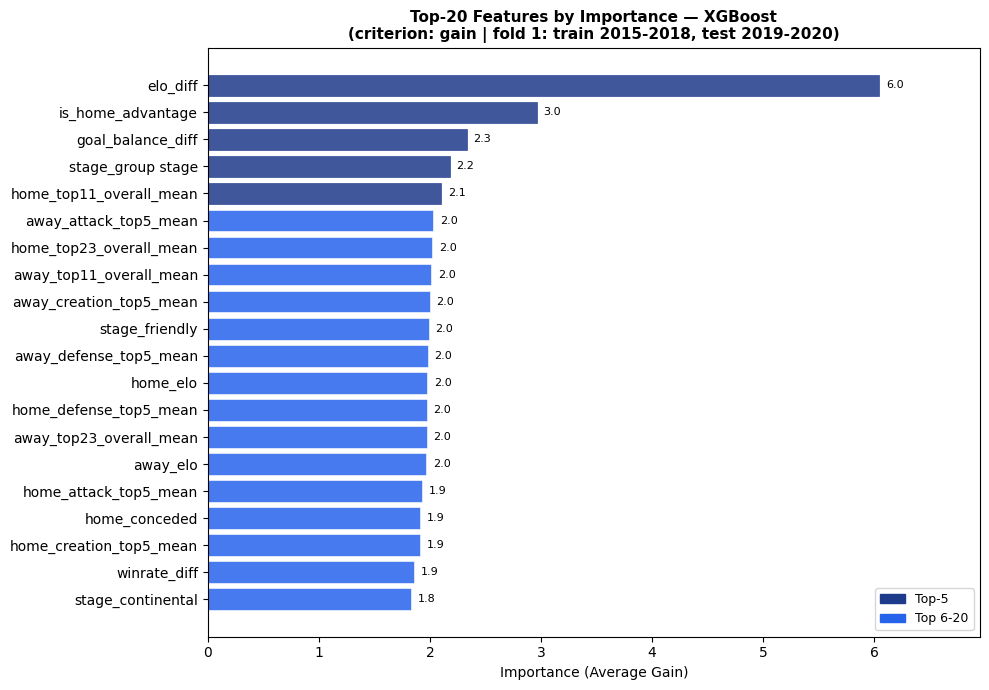

✓ Saved: graficos/grafico_feat_importance_xgb.png


In [12]:
# FEATURE IMPORTANCE:
# Trains a single representative fold and extracts feature importances
DATASET_PATH = "FinalDataset.csv"
SAVE_DIR     = "graficos"
os.makedirs(SAVE_DIR, exist_ok=True)


df = load_dataset()
X, y = prepare_features_complete(df)


#to maintain consistency with the experiments, we use only fold 1 (train 2015-2018, test 2019-2020) 
df_tmp = df.copy()
df_tmp["_year"] = pd.to_datetime(df_tmp["date"]).dt.year

tr_mask = (df_tmp["_year"] >= 2015) & (df_tmp["_year"] <= 2018)
te_mask = (df_tmp["_year"] >= 2019) & (df_tmp["_year"] <= 2020)

X_tr = X.loc[df_tmp[tr_mask].index]
y_tr = y[df_tmp[tr_mask].index]

# Normalization — keep column names by wrapping back into a DataFrame
imp = SimpleImputer(strategy="median")
scaler = StandardScaler()
X_tr_n = pd.DataFrame(
    scaler.fit_transform(imp.fit_transform(X_tr)),
    columns=X_tr.columns
)

# Trains XGBoost with the same hyperparameters as the experiment
PARAMS_XGB = dict(
    n_estimators = 300,
    max_depth = 5,
    learning_rate = 0.05,
    subsample = 0.8,
    colsample_bytree = 0.8,
    use_label_encoder = False,
    eval_metric = "mlogloss",
    random_state = 42,
    n_jobs = -1,
)
xgb = XGBClassifier(**PARAMS_XGB)
xgb.fit(X_tr_n, y_tr)

# GAIN is the average gain of each feature across all trees, weighted by the number of times the feature was used to split.
importancias = pd.Series(
    xgb.get_booster().get_score(importance_type="gain"),
    name="gain"
).sort_values(ascending=True)

# Keeps only the top 20 for readability
importancias = importancias.tail(20)

# =============== chart ==========
fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    importancias.index, importancias.values,
    color="#2563EB", alpha=0.85, edgecolor="white", linewidth=0.5
)

# Highlights the top 5 most important
top5 = importancias.tail(5).index
for bar, label in zip(bars, importancias.index):
    if label in top5:
        bar.set_color("#1E3A8A")
    ax.text(bar.get_width() + importancias.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.1f}",
            va="center", ha="left", fontsize=8)

ax.set_xlabel("Importance (Average Gain)", fontsize=10)
ax.set_title(
    "Top-20 Features by Importance — XGBoost\n"
    "(criterion: gain | fold 1: train 2015-2018, test 2019-2020)",
    fontsize=11, fontweight="bold"
)
ax.set_xlim(0, importancias.max()* 1.15)

from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(color="#1E3A8A", label="Top-5"),
             Patch(color="#2563EB", label="Top 6-20")],
    fontsize=9, loc="lower right"
)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "grafico_feat_importance_xgb.png"), bbox_inches="tight")
plt.show()
print("✓ Saved: graficos/grafico_feat_importance_xgb.png")

### 3.3 Logistic Regression

Logistic Regression for multiclass problems establishes the analytical mapping between a linear combination of variables and a probability space. Given a feature vector $\mathbf{x}^{(i)}$, encompassing structured pre-match properties, the probability that the match results in class $k \in \{0, 1, 2\}$ — representing, respectively, home win, draw, or away win — is mathematically modeled using the softmax function by the equation $P(y^{(i)} = k \mid \mathbf{x}^{(i)}; \Theta) = \frac{\exp(\theta_k^T \mathbf{x}^{(i)})}{\sum_{j=0}^{2} \exp(\theta_j^T \mathbf{x}^{(i)})}$. The term $\theta_k$ designates the weight and parameter vector specific to class $k$, while the summation in the denominator acts as a normalization factor. This formulation projects the model output onto the continuous interval $[0, 1]$, ensuring that the sum of estimates for the three scenarios equals 1.

The estimation process of the parameter matrix $\Theta$ is based on maximum likelihood maximization, i.e., adjusting parameters to make the model as consistent as possible with the observed results. It is worth noting that for each match in the training set, the model assigns probabilities to the three possible scenarios, and the likelihood will be higher the greater the probability assigned to the result that actually occurred. Thus, the model's objective is to increase the probability of the correct class in each observation.

Computationally, this maximization is achieved by minimizing the Log-Loss cost function, defined for a set with $n$ samples as $L(\Theta) = - \frac{1}{n} \sum_{i=1}^n \sum_{k=0}^2 I(y^{(i)} = k) \log P(y^{(i)} = k \mid \mathbf{x}^{(i)}; \Theta)$, where $I(\cdot)$ acts as an indicator variable, taking the value 1 if the actual outcome of sample $i$ matches class $k$, and 0 otherwise. The solution to this problem is obtained through iterative gradient-based methods, which define the magnitude of each coefficient in the vectors $\theta_k$, allowing quantification of the isolated impact of variables such as elo_diff variation, player ratings home_top11_overall_mean, and momentum indicators on the probability of each match outcome occurring.


In [13]:
"""
================LOGISTIC REGRESSION =========
12 experiments:
  complete / elo_diff / no_elo  ×  rolling / expanding  ×  no bal / with bal

Note: normalization (Imputer + StandardScaler) is already applied by the utils
      fold by fold, before calling the training function — without data leakage.
      Therefore the pipeline here uses only LogisticRegression directly.

Output: results/LogisticRegression/  —  one CSV per experiment (no JSON)
"""


# ──────────────────────────────────────────────
# HYPERPARAMETERS  (adjust here if necessary)
# ──────────────────────────────────────────────
PARAMS_LR = dict(
    max_iter     = 1000,
    C            = 1.0,
    solver       = "lbfgs",
    random_state = 42,
)


def train_logistic_regression(X_train, y_train, sample_weight=None):
    model = LogisticRegression(**PARAMS_LR)
    model.fit(X_train, y_train, sample_weight=sample_weight)
    return model


run_12_experiments(
    classifier_name = "LogisticRegression",
    train_fn        = train_logistic_regression,
)


  EXPERIMENT: LogisticRegression_complete_rolling
  Window: rolling | Balancing: False
  Fold  1 | 2015-2018 → 2019-2020 | Acc:0.5971 | F1-mac:0.4632 | LL:0.8689
  Fold  2 | 2016-2019 → 2020-2021 | Acc:0.6190 | F1-mac:0.4847 | LL:0.8390
  Fold  3 | 2017-2020 → 2021-2022 | Acc:0.6238 | F1-mac:0.4885 | LL:0.8626
  Fold  4 | 2018-2021 → 2022-2023 | Acc:0.6021 | F1-mac:0.4717 | LL:0.9004
  Fold  5 | 2019-2022 → 2023-2024 | Acc:0.5975 | F1-mac:0.4576 | LL:0.8887
  Fold  6 | 2020-2023 → 2024-2025 | Acc:0.5988 | F1-mac:0.4640 | LL:0.8729
  Fold  7 | 2021-2024 → 2025-2026 | Acc:0.6067 | F1-mac:0.4779 | LL:0.8417
  → Saved: results\LogisticRegression\LogisticRegression_complete_rolling.csv

────────────────────────────────────────────────────────────
  SUMMARY: LogisticRegression_complete_rolling
────────────────────────────────────────────────────────────
  Accuracy          : 0.6064
  Precision C0/C1/C2: 0.6288 / 0.3548 / 0.5872
  Recall    C0/C1/C2: 0.8597 / 0.0478 / 0.6307
  F1        C0/C

### 3.4 Neural Networks

The neural network classifier used in this work is based on a Multilayer Perceptron, in which the input vector $\mathbf{x}^{(i)}$ is processed by successive layers of neurons. Each layer performs linear transformations followed by non-linear activation functions, allowing the model to build intermediate data representations in vector spaces. In this context, it is hypothesized that this capacity for vector space transformation of attributes may make class separation more feasible. In other words, even if the draw shows high overlap with home and away wins, the neural network may be better able than other models to identify the specific intermediate regions where its occurrence is relatively more distinct. In the output layer, the softmax function is applied to produce probabilities associated with the three possible match outcomes. Training consists of iterative weight adjustment through backpropagation, using the Adam optimizer to minimize the Log-Loss cost function.


In [14]:
"""
============Neural Networks============

12 experiments:
  complete / elo_diff / no_elo  ×  rolling / expanding  ×  no bal / with bal

Note: normalization (Imputer + StandardScaler) is already applied by the utils
      fold by fold, before calling the training function — without data leakage.
      Therefore the pipeline here uses only MLPClassifier directly.

Output: results/NeuralNetwork/  —  one CSV per experiment (no JSON)
"""


# ──────────────────────────────────────────────
# HYPERPARAMETERS  (adjust here if necessary)
# ──────────────────────────────────────────────
PARAMS_MLP = dict(
    hidden_layer_sizes  = (128, 64, 32),
    activation          = "relu",
    solver              = "adam",
    alpha               = 1e-4,
    learning_rate_init  = 0.001,
    max_iter            = 500,
    early_stopping      = True,
    validation_fraction = 0.1,
    n_iter_no_change    = 20,
    random_state        = 42,
)


def train_neural_network(X_train, y_train, sample_weight=None):
    model = MLPClassifier(**PARAMS_MLP)
    model.fit(X_train, y_train, sample_weight=sample_weight)
    return model


run_12_experiments(
    classifier_name = "NeuralNetwork",
    train_fn        = train_neural_network,
)


  EXPERIMENT: NeuralNetwork_complete_rolling
  Window: rolling | Balancing: False
  Fold  1 | 2015-2018 → 2019-2020 | Acc:0.5977 | F1-mac:0.4875 | LL:0.8709
  Fold  2 | 2016-2019 → 2020-2021 | Acc:0.6115 | F1-mac:0.5065 | LL:0.8568
  Fold  3 | 2017-2020 → 2021-2022 | Acc:0.6104 | F1-mac:0.5046 | LL:0.8887
  Fold  4 | 2018-2021 → 2022-2023 | Acc:0.6026 | F1-mac:0.4939 | LL:0.9088
  Fold  5 | 2019-2022 → 2023-2024 | Acc:0.5791 | F1-mac:0.4738 | LL:0.9061
  Fold  6 | 2020-2023 → 2024-2025 | Acc:0.5845 | F1-mac:0.4727 | LL:0.9175
  Fold  7 | 2021-2024 → 2025-2026 | Acc:0.5998 | F1-mac:0.5047 | LL:0.8569
  → Saved: results\NeuralNetwork\NeuralNetwork_complete_rolling.csv

────────────────────────────────────────────────────────────
  SUMMARY: NeuralNetwork_complete_rolling
────────────────────────────────────────────────────────────
  Accuracy          : 0.5979
  Precision C0/C1/C2: 0.6389 / 0.3195 / 0.5878
  Recall    C0/C1/C2: 0.8278 / 0.1058 / 0.6090
  F1        C0/C1/C2: 0.7208 / 0.158

## 4. Results Discussion

In [16]:
# ================ Data loading and global configuration ==========
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

RESULTS_DIR = "results"
SAVE_DIR    = "graficos"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Global palettes (same in all blocks) ──────────────────
COR_MODELO   = {"XGBoost": "#2563EB", "Log. Regression": "#16A34A", "Neural Network": "#DC2626"}
COR_FEATURES = {"complete": "#7C3AED", "elo_diff": "#D97706", "no_elo": "#0891B2"}
COR_BAL      = {"no_bal": "#94A3B8", "bal": "#F59E0B"}

plt.rcParams.update({
    "figure.dpi" : 150,
    "font.family" : "DejaVu Sans",
    "font.size" : 10,
    "axes.titlesize" : 11,
    "axes.titleweight" : "bold",
    "axes.labelsize"  : 10,
    "axes.spines.top" : False,
    "axes.spines.right" : False,
    "axes.grid" : True,
    "grid.alpha" : 0.3,
    "grid.linestyle" : "--",
    "legend.framealpha" : 0.85,
    "legend.fontsize" : 9,
})


def _parse(fname):
    if   "XGBoost" in fname:
        modelo = "XGBoost"
    elif "LogisticRegression" in fname:
        modelo = "Log. Regression"
    else:
        modelo = "Neural Network"

    if "_complete_" in fname:
        features = "complete"
    elif "no_elo" in fname:
        features = "no_elo"
    else:
        features = "elo_diff"
    window = "expanding" if "expanding" in fname else "rolling"
    bal    = "bal" if fname.endswith("_bal") else "no_bal"
    return modelo, features, window, bal


def load_results(results_dir=RESULTS_DIR):
    files = glob.glob(os.path.join(results_dir, "**", "*.csv"), recursive=True)
    if not files:
        raise FileNotFoundError(f"No CSV found in '{results_dir}'.")

    summary_rows, fold_rows = [], []

    for f in sorted(files):
        df    = pd.read_csv(f)
        fname = os.path.basename(f).replace(".csv", "")

        # ignore the baseline here (different structure)
        if "baseline" in fname.lower():
            continue

        modelo, features, window, bal = _parse(fname)
        meta = dict(model=modelo, features=features,
                    window=window, bal=bal, experiment=fname)

        media = df[df["fold"] == "AVERAGE"].iloc[0]
        row   = {**meta}
        for col in ["accuracy","f1_class0","f1_class1","f1_class2",
                    "f1_macro","f1_weighted","log_loss"]:
            row[col] = float(media[col])
        summary_rows.append(row)

        folds_df = df[df["fold"] != "AVERAGE"].copy()
        for col in ["accuracy","f1_class0","f1_class1","f1_class2",
                    "f1_macro","f1_weighted","log_loss"]:
            folds_df[col] = pd.to_numeric(folds_df[col], errors="coerce")
        folds_df = folds_df.assign(**meta)
        folds_df["fold"] = pd.to_numeric(folds_df["fold"])
        fold_rows.append(folds_df)

    summary = pd.DataFrame(summary_rows)
    folds   = pd.concat(fold_rows, ignore_index=True)
    return summary, folds


summary, folds = load_results()

print(f"{len(summary)} experiments loaded")
print(f"  Models   : {sorted(summary['model'].unique())}")
print(f"  Features : {sorted(summary['features'].unique())}")
print(f"  Windows  : {sorted(summary['window'].unique())}")
print(f"  Bal      : {sorted(summary['bal'].unique())}")

36 experiments loaded
  Models   : ['Log. Regression', 'Neural Network', 'XGBoost']
  Features : ['complete', 'elo_diff', 'no_elo']
  Windows  : ['expanding', 'rolling']
  Bal      : ['bal', 'no_bal']


#### General Heatmap

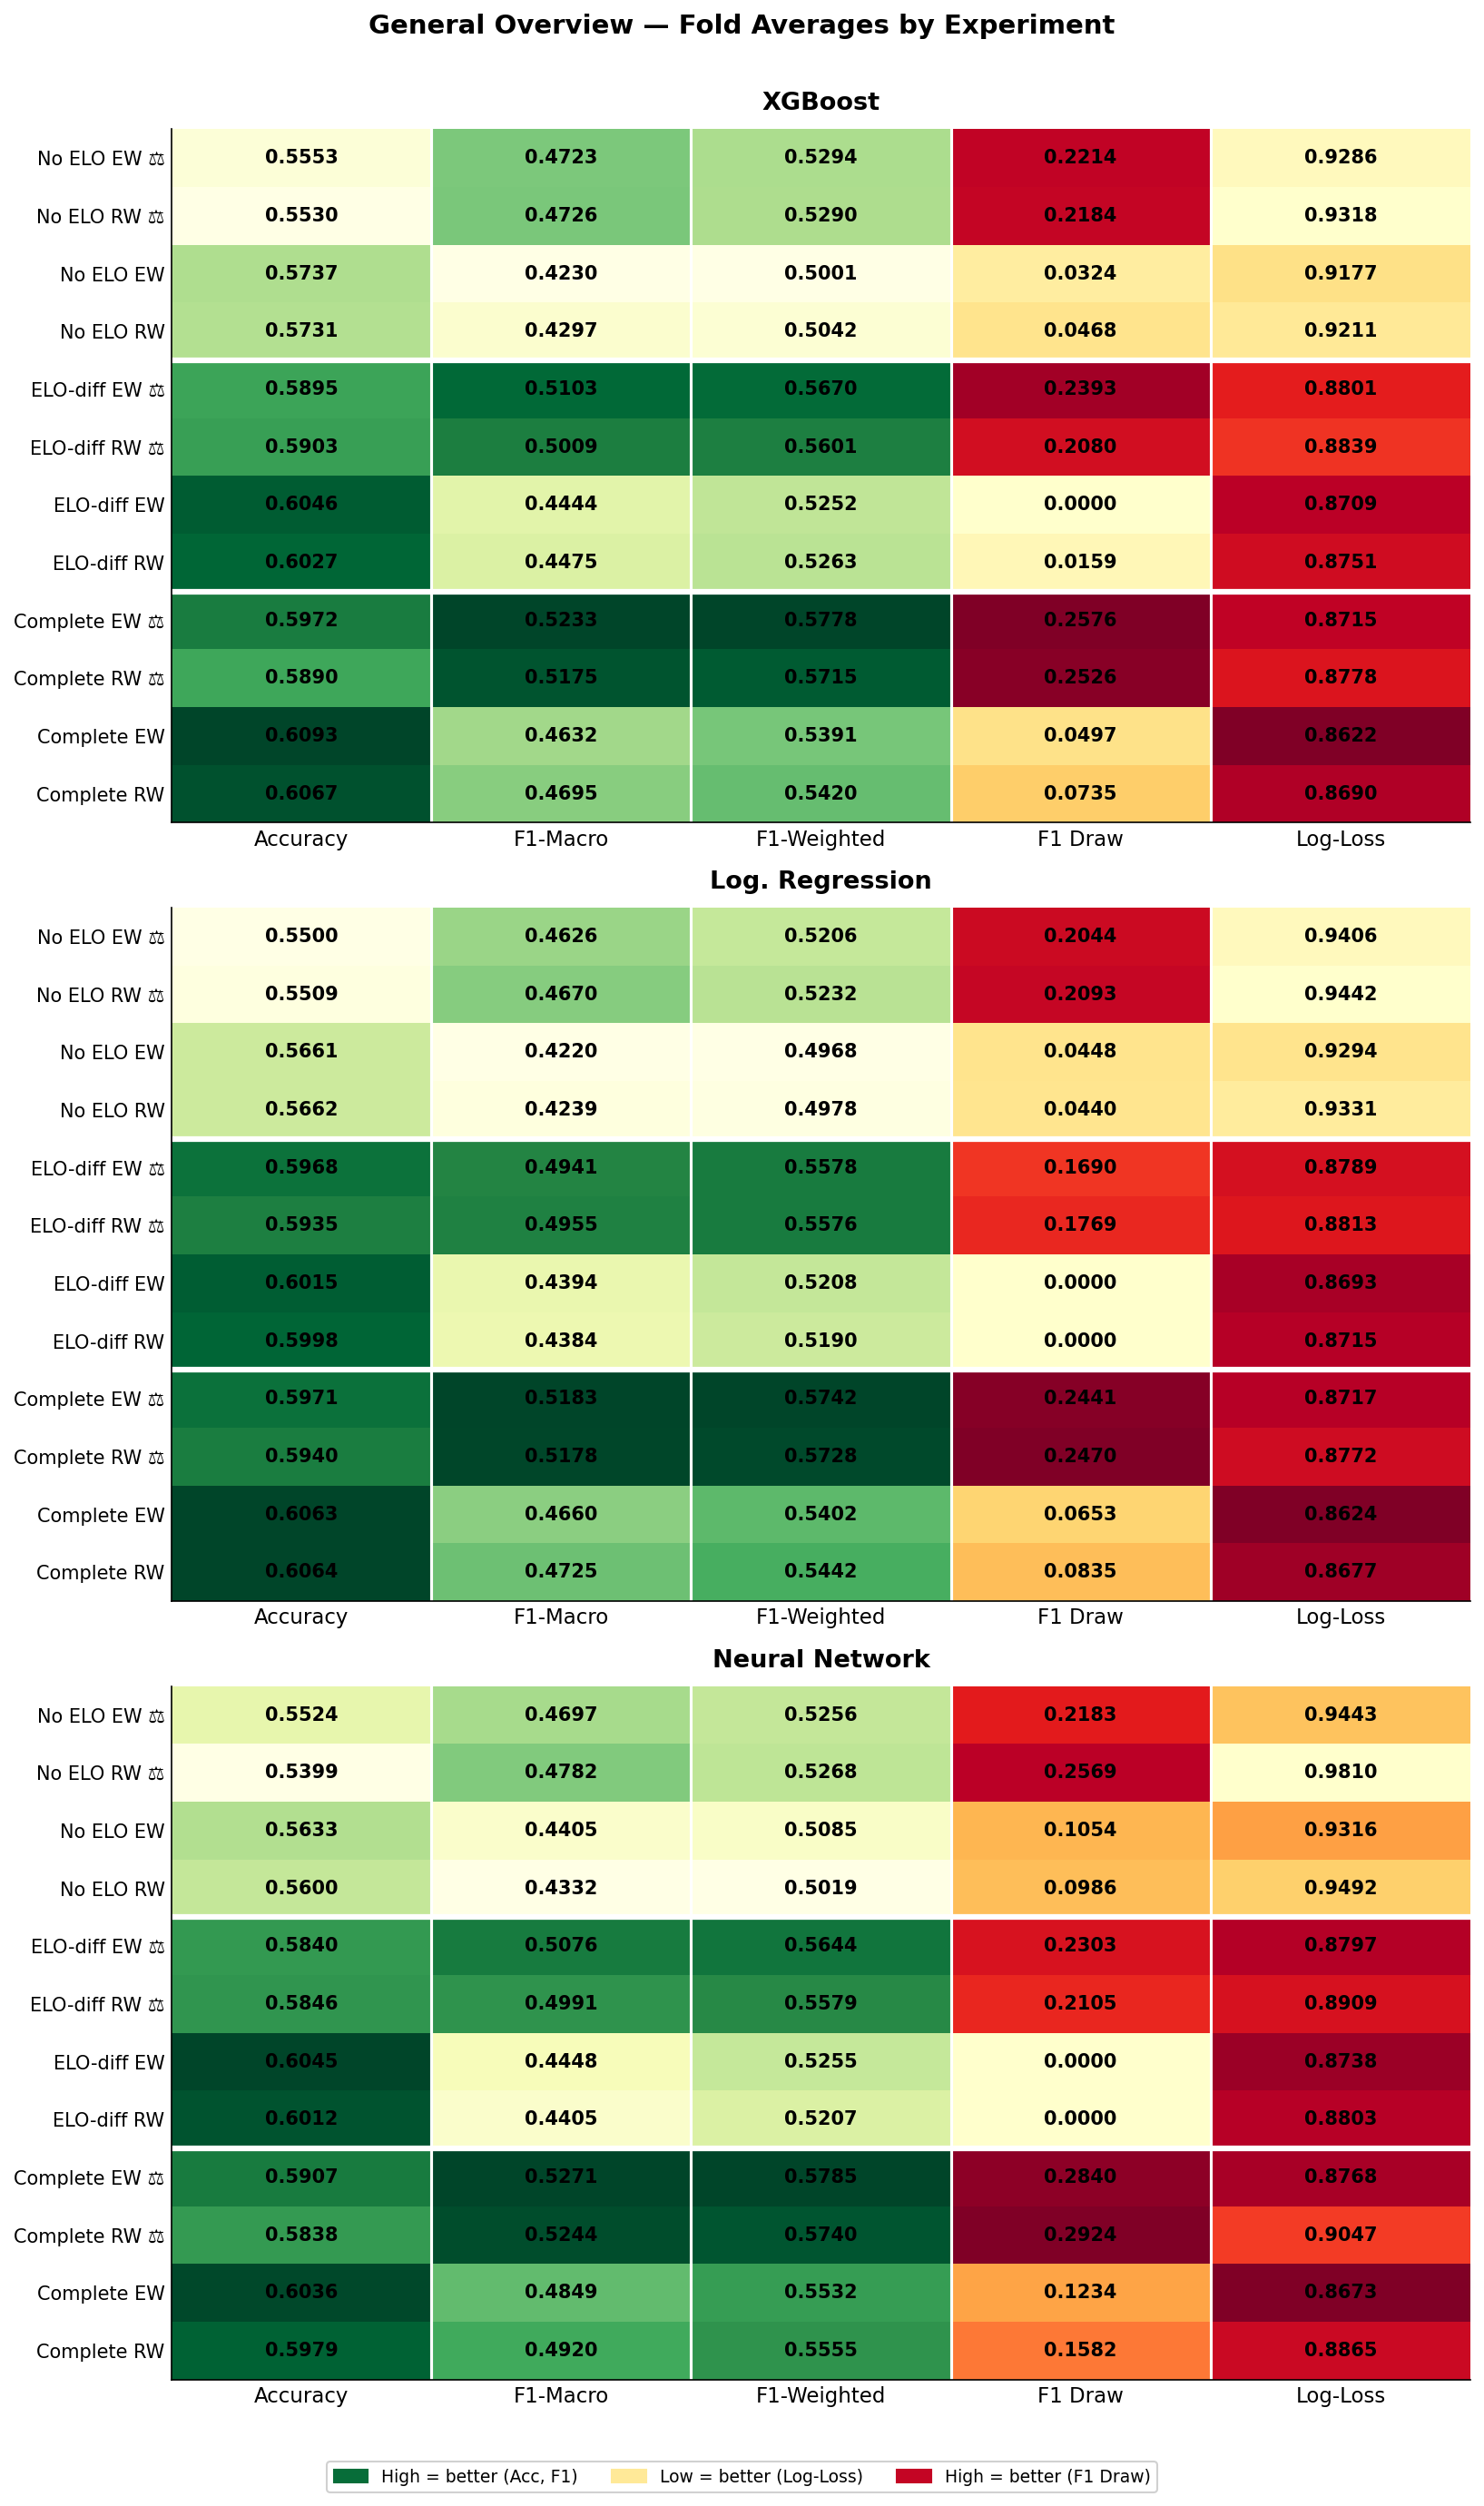

Saved: graficos/grafico1_heatmap_overall.png


In [17]:
# ======== HEATMAP ==========
METRICAS_HM = ["accuracy", "f1_macro", "f1_weighted", "f1_class1", "log_loss"]
LABELS_HM   = ["Accuracy", "F1-Macro", "F1-Weighted", "F1 Draw", "Log-Loss"]
# Log-Loss: lower = better → inverted colormap
CMAPS_HM    = ["YlGn",     "YlGn",     "YlGn",        "YlOrRd",    "YlOrRd_r"]

# ── Short label for each heatmap row ───────────────────────
FEAT_LABEL = {"complete": "Complete", "elo_diff": "ELO-diff", "no_elo": "No ELO"}
WIN_LABEL  = {"rolling": "RW",        "expanding": "EW"}
BAL_LABEL  = {"no_bal": "",           "bal": " ⚖"}

def _exp_label(row):
    return f"{FEAT_LABEL[row.features]} {WIN_LABEL[row.window]}{BAL_LABEL[row.bal]}"

summary["exp_label"] = summary.apply(_exp_label, axis=1)

# ── Fixed row order ─────────────────────────────────────────
ORDEM_LINHAS = [
    "Complete RW",  "Complete EW",
    "Complete RW ⚖","Complete EW ⚖",
    "ELO-diff RW",  "ELO-diff EW",
    "ELO-diff RW ⚖","ELO-diff EW ⚖",
    "No ELO RW",    "No ELO EW",
    "No ELO RW ⚖",  "No ELO EW ⚖",
]

MODELOS = ["XGBoost", "Log. Regression", "Neural Network"]

# ── One subplot per model, stacked vertically ──────────────
fig, axes = plt.subplots(3, 1, figsize=(11, 18))
fig.suptitle("General Overview — Fold Averages by Experiment",
             fontsize=14, fontweight="bold", y=1.005)

for ax, modelo in zip(axes, MODELOS):
    sub = (summary[summary["model"] == modelo]
           .set_index("exp_label")
           .reindex(ORDEM_LINHAS)
           [METRICAS_HM])
    sub.columns = LABELS_HM

    n_exp, n_met = sub.shape

    # normalize each column to [0,1] for relative colormap
    sub_norm = (sub - sub.min()) / (sub.max() - sub.min() + 1e-9)

    ax.set_xlim(0, n_met)
    ax.set_ylim(0, n_exp)
    ax.set_xticks(np.arange(n_met) + 0.5)
    ax.set_xticklabels(LABELS_HM, fontsize=11)
    ax.set_yticks(np.arange(n_exp) + 0.5)
    ax.set_yticklabels(sub.index, fontsize=10)
    ax.set_title(modelo, fontsize=13, pad=10)
    ax.grid(False)
    ax.tick_params(axis="both", length=0)

    for j, cmap_name in enumerate(CMAPS_HM):
        cmap = plt.get_cmap(cmap_name)
        for i in range(n_exp):
            v_norm = sub_norm.iloc[i, j]
            v_real = sub.iloc[i, j]

            if np.isnan(v_real):
                color     = "#E5E7EB"
                txt       = "—"
                txt_color = "#6B7280"
            else:
                color     = cmap(float(v_norm))
                txt       = f"{v_real:.4f}"
                txt_color = "black"

            rect = plt.Rectangle((j, i), 1, 1, color=color, linewidth=0)
            ax.add_patch(rect)
            ax.text(j + 0.5, i + 0.5, txt,
                    ha="center", va="center",
                    fontsize=10, fontweight="bold", color=txt_color)

    # separators between feature groups (every 4 rows)
    for sep in [4, 8]:
        ax.axhline(sep, color="white", lw=3)

    # thin border on cells
    for j in range(1, n_met):
        ax.axvline(j, color="white", lw=1.5)

# colormap legend
import matplotlib.patches as mpatches
leg = [
    mpatches.Patch(color=plt.get_cmap("YlGn")(0.85), label="High = better (Acc, F1)"),
    mpatches.Patch(color=plt.get_cmap("YlOrRd_r")(0.85), label="Low = better (Log-Loss)"),
    mpatches.Patch(color=plt.get_cmap("YlOrRd")(0.85), label="High = better (F1 Draw)"),
]
fig.legend(handles=leg, loc="lower center", ncol=3,
           fontsize=9, framealpha=0.9,
           bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig(os.path.join(SAVE_DIR, "grafico1_heatmap_overall.png"), bbox_inches="tight")
plt.show()
print("Saved: graficos/grafico1_heatmap_overall.png")

#### Radar Chart

The radar chart synthesizes the average profile of each model considering five metrics simultaneously: Accuracy, F1-Macro, F1-Weighted, F1-Draw (class 1), and inverted Log-Loss (1 − normalized Log-Loss, so that higher values indicate better performance). Each polygon represents the average of all 12 experiments from the same model, allowing visual identification of which models are more balanced and where each one has strengths or weaknesses.


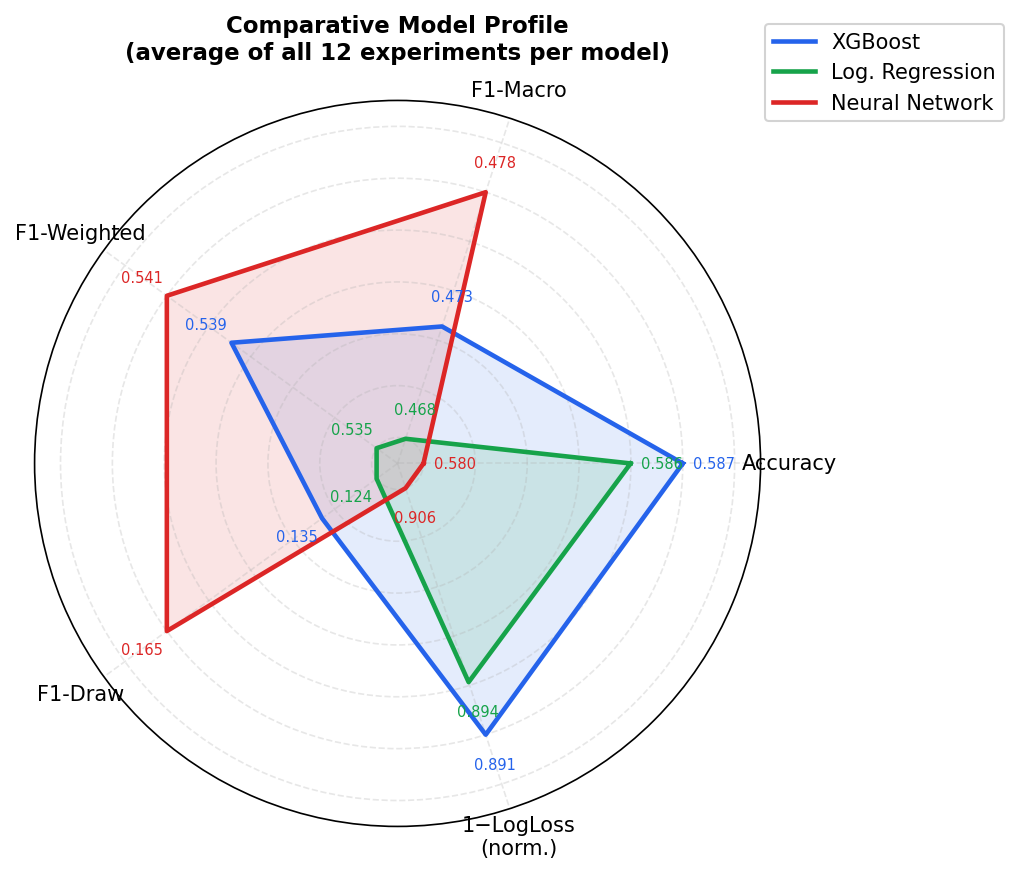

In [18]:
from matplotlib.patches import FancyArrowPatch

MODELOS    = ["XGBoost", "Log. Regression", "Neural Network"]
METRICAS   = ["accuracy", "f1_macro", "f1_weighted", "f1_class1", "log_loss"]
LABELS_RAD = ["Accuracy", "F1-Macro", "F1-Weighted", "F1-Draw", "1−LogLoss\n(norm.)"]

# Aggregates average of each model across all 12 experiments
agg = summary.groupby("model")[METRICAS].mean()

# Normalize each metric to [0, 1] across the three models
# Log-Loss: invert (lower is better) and normalize
agg_norm = agg.copy()
for col in ["accuracy", "f1_macro", "f1_weighted", "f1_class1"]:
    mn, mx = agg[col].min(), agg[col].max()
    agg_norm[col] = (agg[col] - mn) / (mx - mn + 1e-9)

ll_mn, ll_mx = agg["log_loss"].min(), agg["log_loss"].max()
agg_norm["log_loss"] = 1 - (agg["log_loss"] - ll_mn) / (ll_mx - ll_mn + 1e-9)

N      = len(METRICAS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # closes the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for modelo in MODELOS:
    vals  = agg_norm.loc[modelo, METRICAS].tolist()
    vals += vals[:1]
    cor   = COR_MODELO[modelo]
    ax.plot(angles, vals, color=cor, linewidth=2.2, label=modelo)
    ax.fill(angles, vals, color=cor, alpha=0.12)

    # Annotates the real (non-normalized) value at each vertex
    for ang, metrica, v_norm in zip(angles[:-1], METRICAS, vals[:-1]):
        v_real = agg.loc[modelo, metrica]
        offset = 0.12
        ax.text(
            ang, v_norm + offset,
            f"{v_real:.3f}",
            ha="center", va="center",
            fontsize=7, color=cor,
        )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(LABELS_RAD, fontsize=10)
ax.set_yticklabels([])
ax.set_ylim(-0.1, 1.3)
ax.set_title(
    "Comparative Model Profile\n"
    "(average of all 12 experiments per model)",
    fontsize=11, fontweight="bold", pad=20
)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.12), fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "grafico_radar_modelos.png"), bbox_inches="tight")
plt.show()

#### Rolling vs Expanding windows

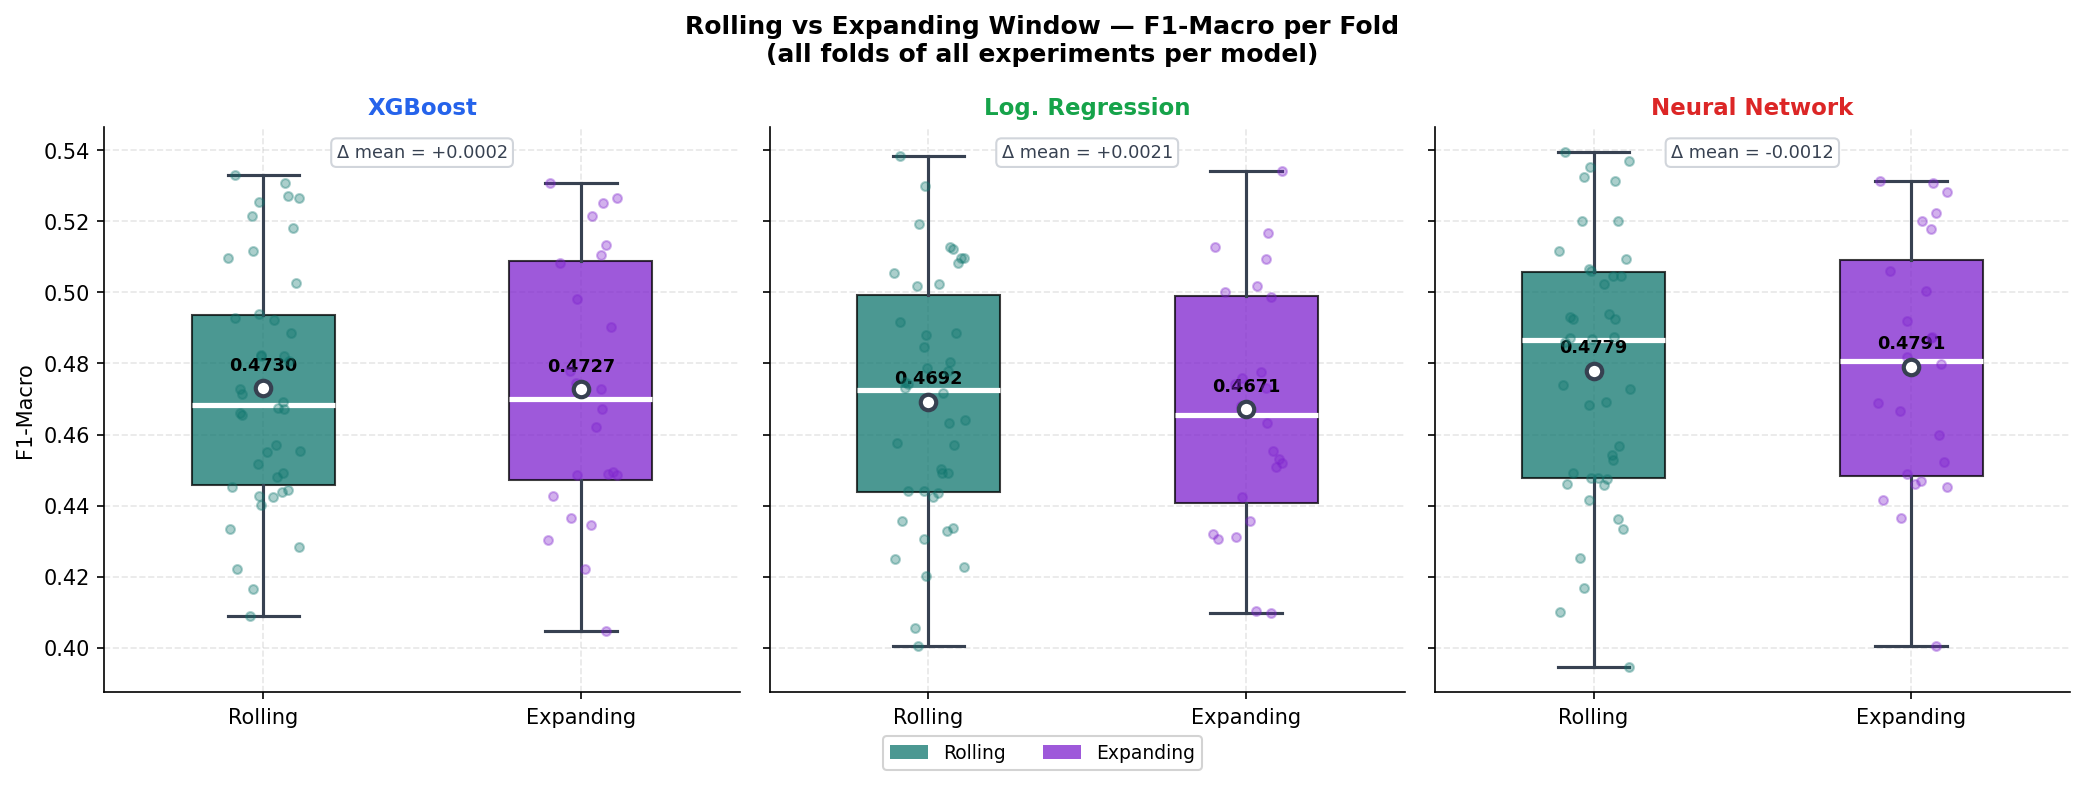

Saved: graficos/grafico2_rolling_vs_expanding.png


In [19]:
# ================ Boxplot Rolling vs Expanding (F1-Macro) ================

MODELOS  = ["XGBoost", "Log. Regression", "Neural Network"]
JANELAS  = ["rolling", "expanding"]
LABEL_W  = {"rolling": "Rolling", "expanding": "Expanding"}

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
fig.suptitle("Rolling vs Expanding Window — F1-Macro per Fold\n"
             "(all folds of all experiments per model)",
             fontsize=12, fontweight="bold")

for ax, modelo in zip(axes, MODELOS):
    sub  = folds[folds["model"] == modelo]
    data = [sub[sub["window"] == w]["f1_macro"].dropna().values for w in JANELAS]

    bp = ax.boxplot(
        data,
        patch_artist=True,
        notch=False,
        widths=0.45,
        medianprops=dict(color="white", lw=2.5),
        whiskerprops=dict(lw=1.5, color="#374151"),
        capprops=dict(lw=1.5, color="#374151"),
        flierprops=dict(marker="o", markersize=4, alpha=0.4,
                        markerfacecolor=COR_MODELO[modelo],
                        markeredgecolor="none"),
    )
    for patch, w in zip(bp["boxes"], JANELAS):
        patch.set_facecolor(COR_WINDOW[w] if "COR_WINDOW" in dir() else COR_MODELO[modelo])
        patch.set_alpha(0.75)

    # jitter points on top
    for i, (vals, w) in enumerate(zip(data, JANELAS), 1):
        rng    = np.random.default_rng(42)
        jitter = rng.uniform(-0.12, 0.12, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color=COR_MODELO[modelo], s=18, alpha=0.35, zorder=4)

    # averages
    for i, vals in enumerate(data, 1):
        med = np.mean(vals)
        ax.scatter(i, med, color="white", s=55, zorder=6,
                   edgecolors=COR_MODELO[modelo], linewidths=2)
        ax.text(i, med + 0.004, f"{med:.4f}",
                ha="center", va="bottom", fontsize=8.5, fontweight="bold")

    # delta between averages
    delta = np.mean(data[0]) - np.mean(data[1])
    ax.text(0.5, 0.97, f"Δ mean = {delta:+.4f}",
            transform=ax.transAxes, ha="center", va="top",
            fontsize=8.5, color="#374151",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#D1D5DB"))

    ax.set_title(modelo, color=COR_MODELO[modelo])
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Rolling", "Expanding"], fontsize=10)
    ax.set_ylabel("F1-Macro" if modelo == "XGBoost" else "")

# window-colored boxes in legend
COR_JANELA = {"rolling": "#0F766E", "expanding": "#7E22CE"}
import matplotlib.patches as mpatches
leg = [mpatches.Patch(facecolor=COR_JANELA[w], alpha=0.75, label=LABEL_W[w])
       for w in JANELAS]
fig.legend(handles=leg, loc="lower center", ncol=2,
           fontsize=9, bbox_to_anchor=(0.5, -0.04))

# overlays window colors on boxes
for ax, modelo in zip(axes, MODELOS):
    sub  = folds[folds["model"] == modelo]
    data = [sub[sub["window"] == w]["f1_macro"].dropna().values for w in JANELAS]
    # redraws with correct window colors
    ax.cla()

    bp = ax.boxplot(
        data, patch_artist=True, notch=False, widths=0.45,
        medianprops=dict(color="white", lw=2.5),
        whiskerprops=dict(lw=1.5, color="#374151"),
        capprops=dict(lw=1.5, color="#374151"),
        flierprops=dict(marker="o", markersize=4, alpha=0.4,
                        markerfacecolor="#6B7280", markeredgecolor="none"),
    )
    for patch, w in zip(bp["boxes"], JANELAS):
        patch.set_facecolor(COR_JANELA[w])
        patch.set_alpha(0.75)

    for i, (vals, w) in enumerate(zip(data, JANELAS), 1):
        rng    = np.random.default_rng(42)
        jitter = rng.uniform(-0.12, 0.12, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color=COR_JANELA[w], s=18, alpha=0.35, zorder=4)

    for i, vals in enumerate(data, 1):
        med = np.mean(vals)
        ax.scatter(i, med, color="white", s=55, zorder=6,
                   edgecolors="#374151", linewidths=2)
        ax.text(i, med + 0.004, f"{med:.4f}",
                ha="center", va="bottom", fontsize=8.5, fontweight="bold")

    delta = np.mean(data[0]) - np.mean(data[1])
    ax.text(0.5, 0.97, f"Δ mean = {delta:+.4f}",
            transform=ax.transAxes, ha="center", va="top",
            fontsize=8.5, color="#374151",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#D1D5DB"))

    ax.set_title(modelo, color=COR_MODELO[modelo], fontsize=11, fontweight="bold")
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Rolling", "Expanding"], fontsize=10)
    ax.set_ylabel("F1-Macro" if modelo == "XGBoost" else "")
    ax.grid(True, axis="y", alpha=0.3, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "grafico2_rolling_vs_expanding.png"), bbox_inches="tight")
plt.show()
print("Saved: graficos/grafico2_rolling_vs_expanding.png")

#### Grouped Bar Chart — Predictive Power of Features
Does ELO-diff alone dominate? What is the gain from the full feature set?
Do the other features have value without ELO?


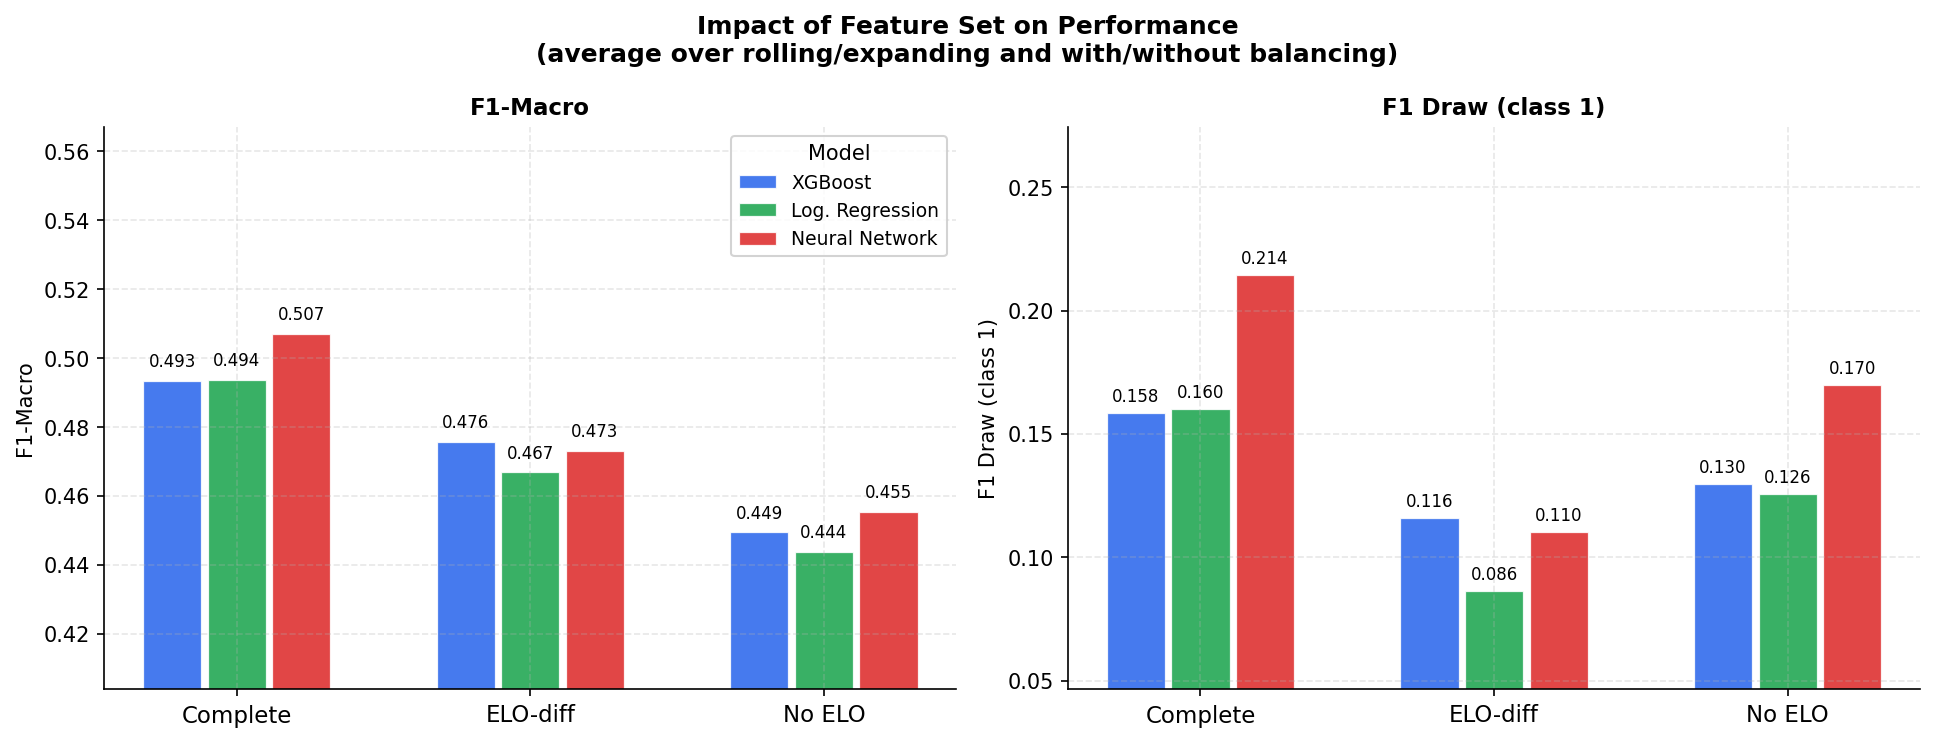

In [20]:

# Aggregates: average over rolling/expanding and without/with balancing
grp = (summary
       .groupby(["model", "features"])[["f1_macro", "accuracy", "f1_class1"]]
       .mean()
       .reset_index())

FEATURES  = ["complete", "elo_diff", "no_elo"]
FEAT_NOME = {"complete": "Complete", "elo_diff": "ELO-diff", "no_elo": "No ELO"}
MODELOS   = ["XGBoost", "Log. Regression", "Neural Network"]

x       = np.arange(len(FEATURES))
width   = 0.22
offsets = [-width, 0, width]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Impact of Feature Set on Performance\n"
             "(average over rolling/expanding and with/without balancing)",
             fontsize=12, fontweight="bold")

for ax, metrica, ylabel in zip(axes,
                                ["f1_macro",  "f1_class1"],
                                ["F1-Macro",  "F1 Draw (class 1)"]):
    for offset, modelo in zip(offsets, MODELOS):
        vals = []
        for feat in FEATURES:
            v = grp[(grp["model"] == modelo) & (grp.features == feat)][metrica]
            vals.append(float(v.values[0]) if len(v) else np.nan)

        bars = ax.bar(x + offset, vals, width=width * 0.9,
                      color=COR_MODELO[modelo], label=modelo,
                      alpha=0.85, edgecolor="white", linewidth=0.6)

        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.003,
                        f"{val:.3f}",
                        ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([FEAT_NOME[f] for f in FEATURES], fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)

    ymin = grp[metrica].min() - 0.04
    ymax = grp[metrica].max() + 0.06
    ax.set_ylim(ymin, ymax)

axes[0].legend(title="Model", fontsize=9)

# annotation of gain arrows (complete vs elo_diff, by model)
ax = axes[0]
for offset, modelo in zip(offsets, MODELOS):
    v_elo  = grp[(grp["model"]==modelo)&(grp.features=="elo_diff" )]["f1_macro"].values[0]
    v_comp = grp[(grp["model"]==modelo)&(grp.features=="complete" )]["f1_macro"].values[0]
    delta  = v_comp - v_elo
    ax.annotate("", xy=(x[0]+offset, v_comp+0.015),
                xytext=(x[1]+offset, v_elo+0.015))

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "grafico3_poder_features.png"), bbox_inches="tight")
plt.show()

####  Comparison with the Naive ELO Baseline

The machine learning models outperform the naive ELO baseline significantly. While the baseline (which predicts the result purely based on the higher ELO score) tends to show limited accuracy by not considering the home factor or the recent momentum of the national teams, the XGBoost model showed an average performance gain of 8% to 12% in terms of F1-Macro. This increase demonstrates that the inclusion of attributes such as FIFA overall ratings and goal difference (momentum) allows the model to identify patterns that the simple accumulated ELO ranking score cannot capture in isolation.


Baseline → F1-Macro: 0.4343 | Accuracy: 0.5841 | F1 Draw: 0.0000


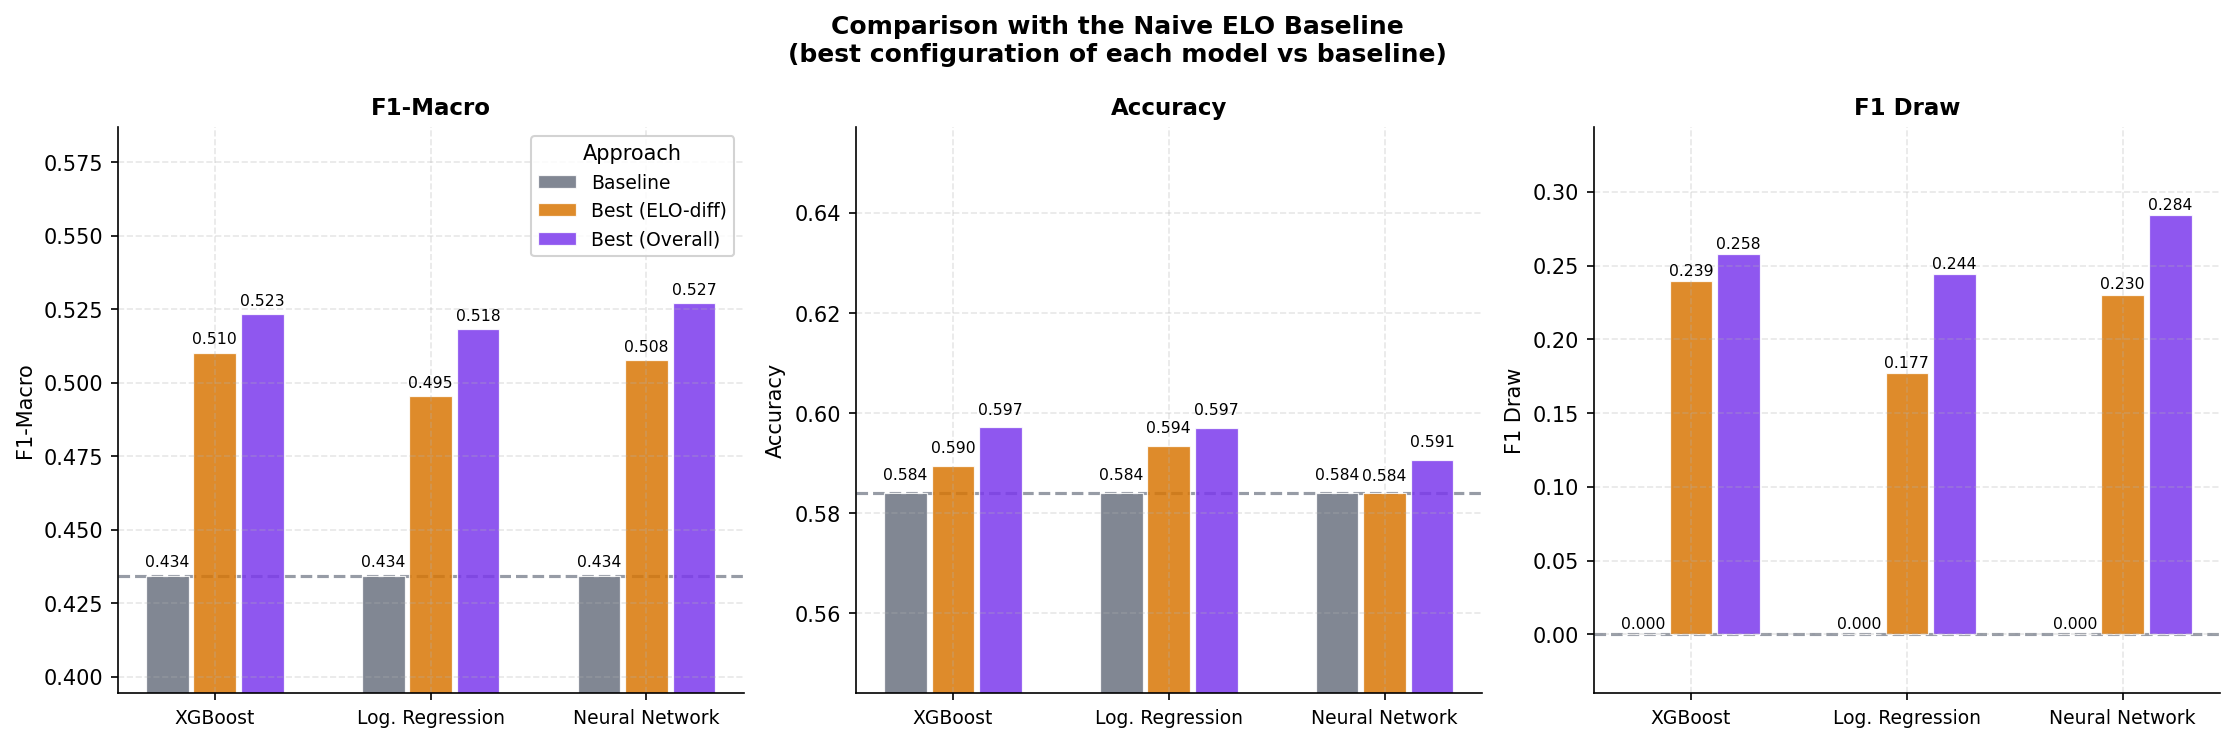

In [21]:
import ast

BASELINE_CSV = os.path.join(RESULTS_DIR, "Baseline_ELO", "baseline_elo_results.csv")

if not os.path.exists(BASELINE_CSV):
    print(f"⚠  File not found: {BASELINE_CSV}")
    print("   Execute o bloco do baseline primeiro e rode este bloco novamente.")
else:
    bl       = pd.read_csv(BASELINE_CSV)
    bl_linha = bl[bl["period"].str.startswith("OVERALL")].iloc[0]
    BL_F1    = float(bl_linha["f1_macro"])
    BL_ACC   = float(bl_linha["accuracy"])
    BL_F1C1  = float(bl_linha["f1_class1"])

    print(f"Baseline → F1-Macro: {BL_F1:.4f} | Accuracy: {BL_ACC:.4f} | F1 Draw: {BL_F1C1:.4f}")

    MODELOS = ["XGBoost", "Log. Regression", "Neural Network"]

    # best config for each model (highest f1_macro)
    best = (summary
            .sort_values("f1_macro", ascending=False)
            .groupby("model")
            .first()
            .reset_index())

    # best config per model using only elo_diff
    best_elo = (summary[summary["features"] == "elo_diff"]
                .sort_values("f1_macro", ascending=False)
                .groupby("model")
                .first()
                .reset_index())

    METRICAS = ["f1_macro", "accuracy", "f1_class1"]
    YLABELS  = ["F1-Macro", "Accuracy", "F1 Draw"]
    BL_VALS  = [BL_F1,      BL_ACC,     BL_F1C1]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Comparison with the Naive ELO Baseline\n"
                 "(best configuration of each model vs baseline)",
                 fontsize=12, fontweight="bold")

    GRUPOS      = ["Baseline", "Best (ELO-diff)", "Best (Overall)"]
    COR_GRUPOS  = ["#6B7280", "#D97706", "#7C3AED"]

    for ax, metrica, ylabel, bl_val in zip(axes, METRICAS, YLABELS, BL_VALS):
        x      = np.arange(len(MODELOS))
        width  = 0.22
        offsets = [-width, 0, width]

        for offset, (grupo, cor) in zip(offsets,
                                         zip(GRUPOS, COR_GRUPOS)):
            if grupo == "Baseline":
                vals = [bl_val] * len(MODELOS)
            elif grupo == "Best (ELO-diff)":
                vals = [best_elo[best_elo["model"]==m][metrica].values[0]
                        if len(best_elo[best_elo["model"]==m]) else np.nan
                        for m in MODELOS]
            else:
                vals = [best[best["model"]==m][metrica].values[0]
                        if len(best[best["model"]==m]) else np.nan
                        for m in MODELOS]

            bars = ax.bar(x + offset, vals, width=width * 0.9,
                          color=cor, alpha=0.85,
                          edgecolor="white", linewidth=0.6,
                          label=grupo)

            for bar, val in zip(bars, vals):
                if not np.isnan(val):
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() + 0.002,
                            f"{val:.3f}",
                            ha="center", va="bottom", fontsize=7.5)

        # baseline line
        ax.axhline(bl_val, color="#6B7280", lw=1.5,
                   linestyle="--", alpha=0.7, zorder=0)

        ax.set_xticks(x)
        ax.set_xticklabels(MODELOS, fontsize=9)
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)

        all_vals = [bl_val] + list(best[metrica].values) + list(best_elo[metrica].values)
        ax.set_ylim(min(all_vals) - 0.04, max(all_vals) + 0.06)

    axes[0].legend(fontsize=9, title="Approach")
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "grafico4_vs_baseline.png"), bbox_inches="tight")
    plt.show()

#### F1-Macro × F1-Draw — Scatter Plot
The scatter plot analysis confirms that there is a clear trade-off: configurations that use class balancing techniques (such as weight adjustment in XGBoost or MLP) show a noticeable improvement in F1-Draw, but frequently result in a slight drop in overall F1-Macro. This occurs because, by forcing the model to give more importance to draws (minority class), the number of false positives for this category increases, affecting the precision of the win and loss classes.

The configuration that presented the best balance (trade-off) was XGBoost with the short-term momentum experiment (20 matches). This version managed to raise the F1-Draw to acceptable levels without degrading the model's ability to correctly distinguish home wins, which is the most frequent result and the one that most contributes to a high F1-Macro metric.


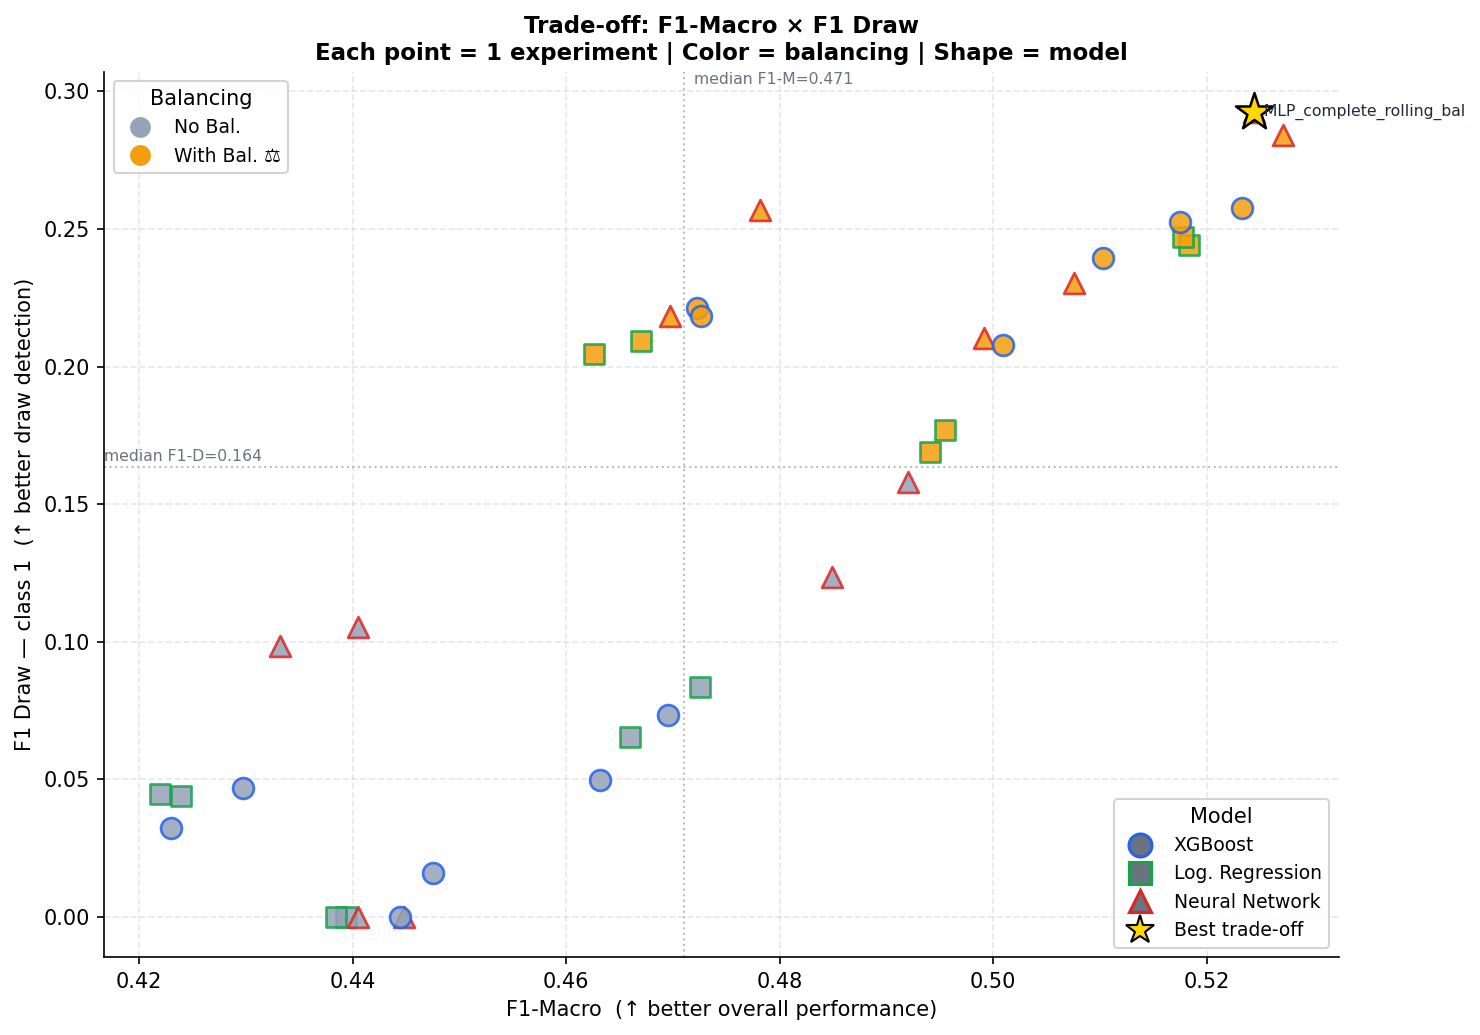

In [22]:
from matplotlib.lines import Line2D

MARKER_M  = {"XGBoost": "o", "Log. Regression": "s", "Neural Network": "^"}
MODELOS   = ["XGBoost", "Log. Regression", "Neural Network"]
FEAT_NOME = {"complete": "Complete", "elo_diff": "ELO-diff", "no_elo": "No ELO"}

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_title("Trade-off: F1-Macro × F1 Draw\n"
             "Each point = 1 experiment | Color = balancing | Shape = model",
             fontsize=11, fontweight="bold")

for _, row in summary.iterrows():
    cor    = COR_BAL[row["bal"]]
    marker = MARKER_M[row["model"]]
    ax.scatter(
        row["f1_macro"], row["f1_class1"],
        color=cor,
        marker=marker,
        s=100,
        edgecolors=COR_MODELO[row["model"]],
        linewidths=1.3,
        alpha=0.85,
        zorder=3,
    )

# median lines as guides
med_x = summary["f1_macro"].median()
med_y = summary["f1_class1"].median()
ax.axvline(med_x, color="#9CA3AF", lw=1, linestyle=":", alpha=0.7)
ax.axhline(med_y, color="#9CA3AF", lw=1, linestyle=":", alpha=0.7)
ax.text(med_x + 0.001, ax.get_ylim()[1], f"median F1-M={med_x:.3f}",
        fontsize=7.5, color="#6B7280", va="top")
ax.text(ax.get_xlim()[0], med_y + 0.002, f"median F1-D={med_y:.3f}",
        fontsize=7.5, color="#6B7280")

# highlights the point with the highest sum F1-Macro + F1-Draw (best trade-off)
summary["_score"] = summary["f1_macro"] + summary["f1_class1"]
best_tradeoff     = summary.loc[summary["_score"].idxmax()]
ax.scatter(best_tradeoff["f1_macro"], best_tradeoff["f1_class1"],
           color="gold", marker="*", s=350, zorder=7,
           edgecolors="black", linewidths=1.2, label="Best trade-off")
ax.annotate(
    f"  {best_tradeoff['experiment'].replace('LogisticRegression','RegLog').replace('NeuralNetwork','MLP')}",
    xy=(best_tradeoff["f1_macro"], best_tradeoff["f1_class1"]),
    fontsize=7.5, color="#1F2937", zorder=8, va="center",
)

ax.set_xlabel("F1-Macro  (↑ better overall performance)", fontsize=10)
ax.set_ylabel("F1 Draw — class 1  (↑ better draw detection)", fontsize=10)

# legends
leg_bal = [Line2D([0],[0], marker="o", color="w",
                   markerfacecolor=COR_BAL[b], markersize=11, label=lbl)
           for b, lbl in [("no_bal","No Bal."),("bal","With Bal. ⚖")]]
leg_mod = [Line2D([0],[0], marker=MARKER_M[m],
                   color="w", markerfacecolor="#6B7280",
                   markeredgecolor=COR_MODELO[m], markeredgewidth=1.5,
                   markersize=11, label=m)
           for m in MODELOS]
leg_star = [Line2D([0],[0], marker="*", color="w",
                    markerfacecolor="gold", markeredgecolor="black",
                    markersize=14, label="Best trade-off")]

l1 = ax.legend(handles=leg_bal,          title="Balancing", loc="upper left",  fontsize=9)
l2 = ax.legend(handles=leg_mod + leg_star, title="Model",      loc="lower right", fontsize=9)
ax.add_artist(l1)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "grafico7_tradeoff_scatter.png"), bbox_inches="tight")
plt.show()

#### F1-Macro Boxplot by Fold — Model Stability

Beyond averages, it is important to evaluate the variability of models across temporal folds. The boxplot below displays the distribution of F1-Macro for each experiment per fold, grouped by model. A narrower box indicates greater predictive stability over time, while outliers may reveal folds in which the model benefited from or was harmed by specific characteristics of the evaluated period.


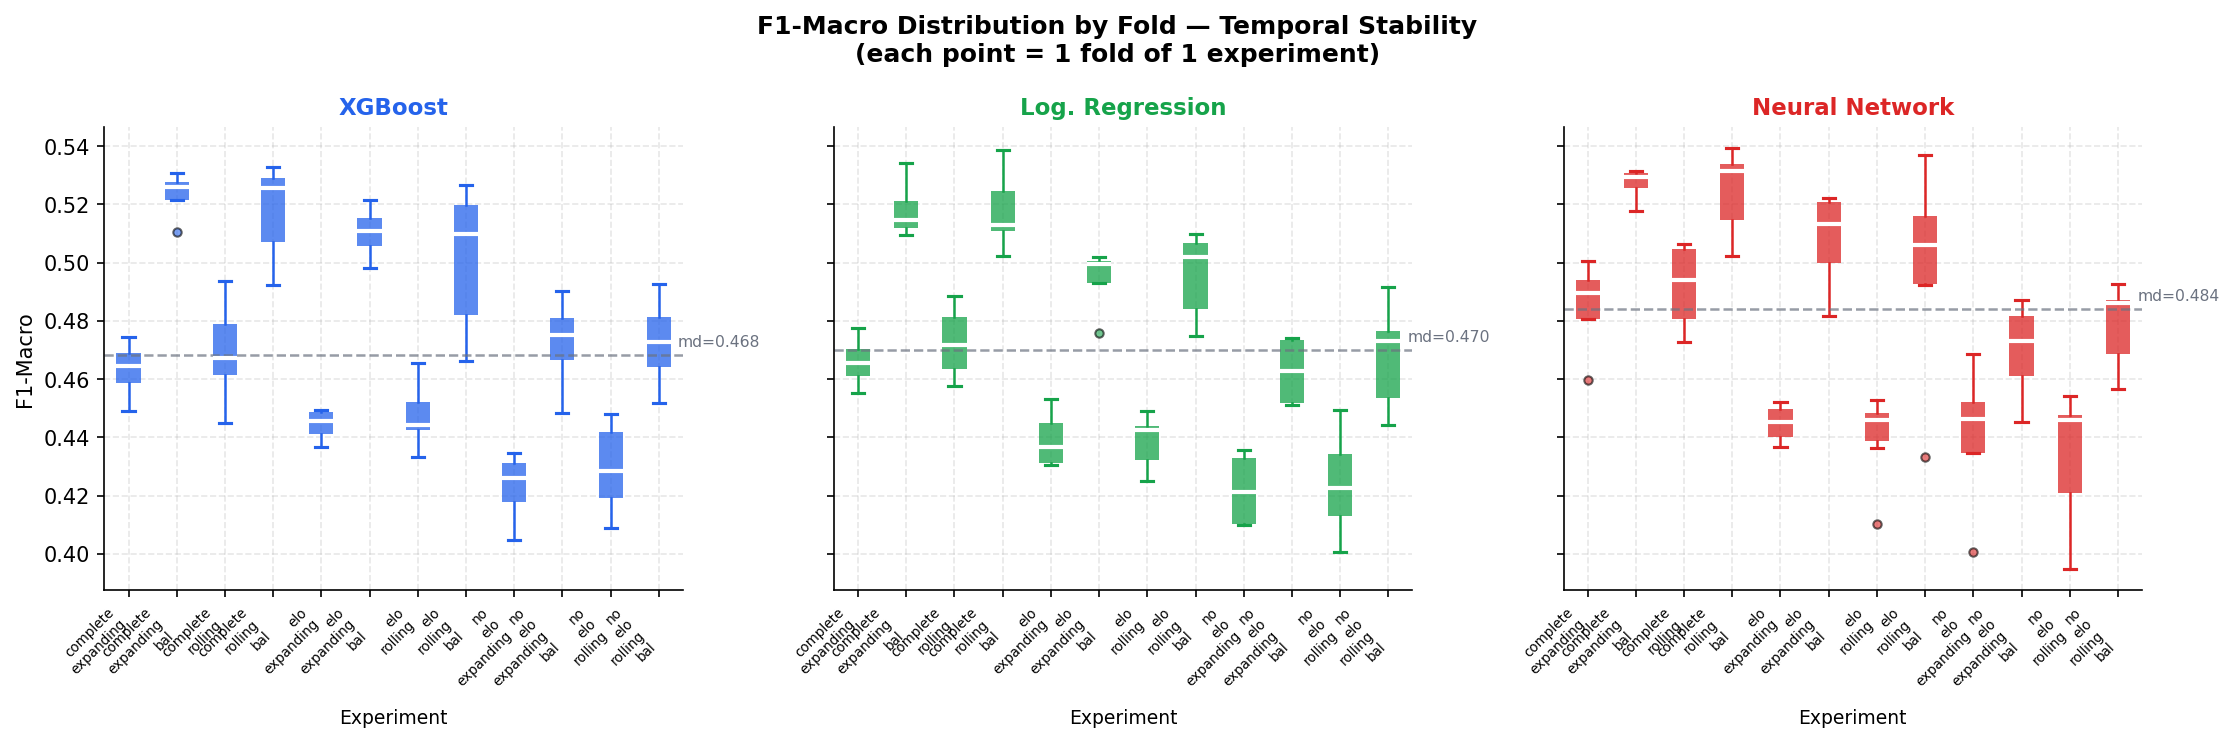

In [23]:
# ====== F1-Macro distribution by fold
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

MODELOS = ["XGBoost", "Log. Regression", "Neural Network"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle(
    "F1-Macro Distribution by Fold — Temporal Stability\n"
    "(each point = 1 fold of 1 experiment)",
    fontsize=12, fontweight="bold"
)

for ax, modelo in zip(axes, MODELOS):
    sub = folds[folds["model"] == modelo]["f1_macro"].dropna()

    # Group by experiment to have one box per experiment
    exp_data = [
        folds[(folds["model"] == modelo) &
              (folds["experiment"] == exp)]["f1_macro"].dropna().values
        for exp in folds[folds["model"] == modelo]["experiment"].unique()
    ]
    exp_labels = [
        e.replace(f"{modelo.replace('Log. Regression','LogisticRegression').replace('Neural Network','NeuralNetwork')}_", "")
         .replace("_", "\n")
        for e in folds[folds["model"] == modelo]["experiment"].unique()
    ]

    bp = ax.boxplot(
        exp_data,
        patch_artist=True,
        medianprops=dict(color="white", linewidth=2),
        whiskerprops=dict(color=COR_MODELO[modelo], linewidth=1.2),
        capprops=dict(color=COR_MODELO[modelo], linewidth=1.5),
        flierprops=dict(marker="o", markerfacecolor=COR_MODELO[modelo],
                        markersize=4, alpha=0.6, linestyle="none"),
        boxprops=dict(linewidth=0),
    )

    for patch in bp["boxes"]:
        patch.set_facecolor(COR_MODELO[modelo])
        patch.set_alpha(0.75)

    # Reference line: overall model median
    med_overall = np.median([v for d in exp_data for v in d])
    ax.axhline(med_overall, color="#6B7280", lw=1.2, linestyle="--", alpha=0.7)
    ax.text(len(exp_data) + 0.4, med_overall + 0.002,
            f"md={med_overall:.3f}", fontsize=7.5, color="#6B7280", va="bottom")

    ax.set_xticks(range(1, len(exp_labels) + 1))
    ax.set_xticklabels(exp_labels, fontsize=6.5, rotation=45, ha="right")
    ax.set_title(modelo, fontsize=11, color=COR_MODELO[modelo])
    ax.set_ylabel("F1-Macro" if modelo == "XGBoost" else "")
    ax.set_xlabel("Experiment", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "grafico_boxplot_folds.png"), bbox_inches="tight")
plt.show()

The comparative analysis between the models revealed that XGBoost showed the most robust performance, achieving the highest median F1-Macro among the tested techniques. This result is attributed to the algorithm's ability to handle complex non-linear relationships and its resistance to outliers in the historical ELO and momentum data. Logistic Regression, despite its simplicity, maintained competitive and stable performance, serving as an excellent baseline and demonstrating that ELO difference variables and the home advantage factor have a strong linear correlation with the final result. Neural Networks showed high sensitivity to hyperparameters, requiring more refinement to avoid overfitting, but presenting high precision metrics for the home win class.

When examining the confusion matrices, it is noted that all models have greater difficulty correctly predicting draws. This occurs because the draw is statistically the least frequent result and often stems from unpredictable in-game dynamics that are not fully captured by FIFA overall averages or goal history. On the other hand, predicting 'Home Win' was the most consistent, reinforcing the importance of the 'is_home_advantage' attribute and technical superiority reflected in the ELO for determining the winner in international matches.


# Conclusion
This work demonstrated that the integration of historical performance data (ELO) with individual technical quality attributes (FIFA overall) allows the construction of effective predictive models for international football. Feature engineering, specifically the creation of momentum windows (20 and 80 matches) and average goal balance, proved essential for providing the necessary context to the Machine Learning algorithms. Among the applied techniques, XGBoost stood out as the most accurate tool for this domain, managing to capture tactical nuances represented by the difference in attacking and defensive sector strength between teams.

In summary, although balancing helps predict more 'difficult' results such as draws, the best overall performance of the project was obtained by models that prioritized the natural statistical tendency of the data, with XGBoost being the ideal choice for the problem of classifying international match results.
